# Model Evaluation Results - Plotting Only

This notebook loads pre-computed evaluation results and generates all visualizations.

**No model inference is performed** - all data comes from the evaluation script output.


## Step 1: Load Pre-computed Results

Load the pickle file created by `evaluate_models.py`


In [70]:
%matplotlib inline
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from scipy.stats import kstest
from sklearn.calibration import calibration_curve

# ========================================================================
# CONFIGURATION: Specify results pickle file(s) to load
# ========================================================================
# You can provide a single path (string) or multiple paths (list of strings)
# If multiple paths are provided, results will be merged/intermingled
RESULTS_PATHS = [
    #"evaluation_results/evaluation_results_250000_cluster.pickle",  
    "evaluation_results/evaluation_results_250000_ablations_cluster.pickle"
    #"evaluation_results/evaluation_results_250000_cross_entropy.pickle"
]

# If you prefer a single file, you can also use:
# RESULTS_PATHS = "evaluation_results_100_faster_learners.pickle"

# Normalize to list format
if isinstance(RESULTS_PATHS, str):
    RESULTS_PATHS = [RESULTS_PATHS]

# Load and merge results from all files
print("Loading evaluation results...")
print(f"Loading {len(RESULTS_PATHS)} result file(s):")
for path in RESULTS_PATHS:
    print(f"  - {path}")

# Initialize merged data structures
mae_examples = []
mae_runners_list = []
xgb_successful_indices = []
results = {}
percentiles_by_model = {}
results_by_history = defaultdict(lambda: defaultdict(list))
results_by_week_delta = defaultdict(lambda: defaultdict(list))
model_config = {}
metadata = {}
example_predictions = []
calibration_data = {}

# Track example indices across files (for merging xgb_successful_indices)
example_offset = 0
seen_model_configs = {}  # Track if same model appears in multiple files
redundancy_info = []  # Track models that appear in multiple files

# Track which file and which indices each model's data came from
# model_data_source[model_name] = {
#     'file': path,
#     'xgb_indices_start': start_idx,
#     'xgb_indices_end': end_idx,
#     'example_offset': offset_at_time
# }
model_data_source = {}  # Track source file and index ranges for each model

for file_idx, results_path in enumerate(RESULTS_PATHS):
    print(f"\nLoading file {file_idx + 1}/{len(RESULTS_PATHS)}: {results_path}")
    try:
        with open(results_path, 'rb') as f:
            data = pickle.load(f)
        
        # Merge examples and runners (append to lists)
        file_examples = data.get('mae_examples', [])
        file_runners = data.get('mae_runners_list', [])
        file_xgb_indices = data.get('xgb_successful_indices', [])
        
        # Store original file data before merging
        file_num_examples = len(file_examples)
        file_num_xgb_successful = len(file_xgb_indices)
        
        # Track where this file's xgb_successful_indices will start in the merged list
        xgb_indices_start = len(xgb_successful_indices)
        
        mae_examples.extend(file_examples)
        mae_runners_list.extend(file_runners)
        
        # Adjust xgb_successful_indices by adding offset
        adjusted_xgb_indices = [idx + example_offset for idx in file_xgb_indices]
        xgb_successful_indices.extend(adjusted_xgb_indices)
        
        # Track where this file's xgb_successful_indices end in the merged list
        xgb_indices_end = len(xgb_successful_indices)
        
        # Track offset for next file
        example_offset += len(file_examples)
        
        # Helper function to generate unique model name (add number suffix if duplicate)
        def get_unique_model_name(base_name, existing_names):
            """Generate a unique model name by adding a number suffix if needed."""
            if base_name not in existing_names:
                return base_name
            
            # Find the highest existing number suffix
            max_num = 0
            for existing_name in existing_names:
                if existing_name == base_name:
                    max_num = max(max_num, 1)  # Original exists, so start at 2
                elif existing_name.startswith(base_name + '_'):
                    try:
                        num = int(existing_name.split('_')[-1])
                        max_num = max(max_num, num)
                    except ValueError:
                        pass
            
            # Return name with next number
            return f"{base_name}_{max_num + 1}"
        
        # Merge results (models) - add number suffix if model appears in multiple files
        # Note: results contain aggregated stats (MAE, RMSE) and error lists
        # Error lists are indexed by position in xgb_successful_indices
        file_results = data.get('results', {})
        for model_name, model_results in file_results.items():
            # Get unique model name (add number suffix if duplicate)
            unique_model_name = get_unique_model_name(model_name, results.keys())
            
            if unique_model_name != model_name:
                print(f"  ⚠️  Model '{model_name}' already exists. Renaming to '{unique_model_name}' to keep both versions.")
                redundancy_info.append({
                    'model': model_name,
                    'file': results_path,
                    'existing_count': len(results.get(model_name, {}).get('errors_mean', [])) if model_name in results else 0,
                    'new_count': len(model_results.get('errors_mean', [])) if isinstance(model_results, dict) else 0,
                    'chosen': f'renamed to {unique_model_name}'
                })
            
            # Store results with unique name
            if isinstance(model_results, dict):
                results[unique_model_name] = {}
                for key, value in model_results.items():
                    if isinstance(value, list):
                        results[unique_model_name][key] = list(value)  # Make a copy
                    else:
                        results[unique_model_name][key] = value
            else:
                results[unique_model_name] = model_results
            
            # Track data source for this model
            model_data_source[unique_model_name] = {
                'file': results_path,
                'xgb_indices_start': xgb_indices_start,
                'xgb_indices_end': xgb_indices_end,
                'example_offset': example_offset - len(file_examples),
                'original_name': model_name  # Track original name for reference
            }
        
        # Merge percentiles_by_model
        # Percentiles are indexed by position in xgb_successful_indices, not by example index
        # IMPORTANT: Use the same unique name that was used for results
        file_percentiles = data.get('percentiles_by_model', {})
        for model_name, percentiles in file_percentiles.items():
            # Find the corresponding unique name in results (should match what was used for results)
            # IMPORTANT: Check for renamed versions FIRST
            unique_model_name = None
            
            # First check if there's a renamed version (e.g., model_name_2) in results
            for res_key in results.keys():
                if res_key.endswith('_2') and res_key[:-2] == model_name:
                    unique_model_name = res_key
                    break
                for suffix_num in range(3, 10):
                    suffix = f'_{suffix_num}'
                    if res_key.endswith(suffix) and res_key[:-len(suffix)] == model_name:
                        unique_model_name = res_key
                        break
                if unique_model_name:
                    break
            
            # If no renamed version found, check if model_name exists in results (from first file)
            if unique_model_name is None:
                if model_name in results:
                    unique_model_name = model_name
                else:
                    unique_model_name = get_unique_model_name(model_name, list(results.keys()))
            
            if unique_model_name != model_name:
                print(f"  ⚠️  Model '{model_name}' percentiles -> '{unique_model_name}' to match results.")
            
            # Verify length matches file's XGBoost indices
            if len(percentiles) != file_num_xgb_successful:
                print(f"  ⚠️  Warning: Model '{unique_model_name}' has {len(percentiles)} percentiles but {file_num_xgb_successful} XGBoost indices in this file.")
            
            # Store percentiles with unique name
            percentiles_by_model[unique_model_name] = list(percentiles)  # Make a copy
            
            # Update data source tracking if not already set
            if unique_model_name not in model_data_source:
                model_data_source[unique_model_name] = {
                    'file': results_path,
                    'xgb_indices_start': xgb_indices_start,
                    'xgb_indices_end': xgb_indices_end,
                    'example_offset': example_offset - len(file_examples),
                    'original_name': model_name
                }
        
        # Merge results_by_history
        # These are indexed by example position in xgb_successful_indices
        # IMPORTANT: Use the same unique name that was used for results
        file_results_by_history = data.get('results_by_history', {})
        for hist_len, model_errors in file_results_by_history.items():
            for model_name, errors in model_errors.items():
                # Find the corresponding unique name in results (should match what was used for results)
                # IMPORTANT: Check for renamed versions FIRST, because if this is the second file,
                # the model might have been renamed (e.g., model_cross_entropy -> model_cross_entropy_2)
                unique_model_name = None
                
                # First check if there's a renamed version (e.g., model_name_2) in results
                # This happens when the second file has the same model name as the first file
                for res_key in results.keys():
                    # Check if this is a renamed version of model_name (ends with _2, _3, etc.)
                    if res_key.endswith('_2') and res_key[:-2] == model_name:
                        unique_model_name = res_key
                        break
                    # Also check for _3, _4, etc. (though unlikely)
                    for suffix_num in range(3, 10):
                        suffix = f'_{suffix_num}'
                        if res_key.endswith(suffix) and res_key[:-len(suffix)] == model_name:
                            unique_model_name = res_key
                            break
                    if unique_model_name:
                        break
                
                # If no renamed version found, check if model_name exists in results (from first file)
                if unique_model_name is None:
                    if model_name in results:
                        unique_model_name = model_name
                    else:
                        # If still not found, use get_unique_model_name (shouldn't happen, but fallback)
                        unique_model_name = get_unique_model_name(model_name, list(results.keys()))
                
                if isinstance(errors, list):
                    results_by_history[hist_len][unique_model_name].extend(errors)
                else:
                    # If it's not a list, just append as single value
                    results_by_history[hist_len][unique_model_name].append(errors)
        
        # Merge results_by_week_delta
        # These are also indexed by example position in xgb_successful_indices
        # IMPORTANT: Use the same unique name that was used for results
        file_results_by_week_delta = data.get('results_by_week_delta', {})
        for week_delta, model_errors in file_results_by_week_delta.items():
            for model_name, errors in model_errors.items():
                # Find the corresponding unique name in results (should match what was used for results)
                # IMPORTANT: Check for renamed versions FIRST, because if this is the second file,
                # the model might have been renamed (e.g., model_cross_entropy -> model_cross_entropy_2)
                unique_model_name = None
                
                # First check if there's a renamed version (e.g., model_name_2) in results
                # This happens when the second file has the same model name as the first file
                for res_key in results.keys():
                    # Check if this is a renamed version of model_name (ends with _2, _3, etc.)
                    if res_key.endswith('_2') and res_key[:-2] == model_name:
                        unique_model_name = res_key
                        break
                    # Also check for _3, _4, etc. (though unlikely)
                    for suffix_num in range(3, 10):
                        suffix = f'_{suffix_num}'
                        if res_key.endswith(suffix) and res_key[:-len(suffix)] == model_name:
                            unique_model_name = res_key
                            break
                    if unique_model_name:
                        break
                
                # If no renamed version found, check if model_name exists in results (from first file)
                if unique_model_name is None:
                    if model_name in results:
                        unique_model_name = model_name
                    else:
                        # If still not found, use get_unique_model_name (shouldn't happen, but fallback)
                        unique_model_name = get_unique_model_name(model_name, list(results.keys()))
                
                if isinstance(errors, list):
                    results_by_week_delta[week_delta][unique_model_name].extend(errors)
                else:
                    results_by_week_delta[week_delta][unique_model_name].append(errors)
        
        # Merge model_config - use unique model name (with number suffix if duplicate)
        file_model_config = data.get('model_config', {})
        for model_name, config in file_model_config.items():
            # Get unique model name (should match the one used for results)
            unique_model_name = get_unique_model_name(model_name, list(results.keys()) + list(model_config.keys()))
            
            if unique_model_name != model_name:
                print(f"  ⚠️  Model '{model_name}' config already exists. Using '{unique_model_name}' to match results.")
            
            # Store config with unique name
            model_config[unique_model_name] = config
            if unique_model_name not in seen_model_configs:
                seen_model_configs[unique_model_name] = config
        
        # Merge metadata (use first file's metadata, or merge if needed)
        if file_idx == 0:
            metadata = data.get('metadata', {})
        else:
            # Optionally merge metadata from other files
            file_metadata = data.get('metadata', {})
            # For now, just keep first file's metadata
            pass
        
        # Merge example_predictions
        file_example_predictions = data.get('example_predictions', [])
        # Adjust example indices in predictions (use offset before it's updated)
        current_offset = example_offset
        for pred in file_example_predictions:
            if 'example_idx' in pred:
                pred['example_idx'] = pred['example_idx'] + current_offset
        example_predictions.extend(file_example_predictions)
        
        # Merge calibration_data - use unique model name (with number suffix if duplicate)
        # IMPORTANT: Use the same unique name that was used for results/percentiles
        file_calibration_data = data.get('calibration_data', {})
        for model_name, cal_data in file_calibration_data.items():
            # Find the corresponding unique name in results (should match what was used for results/percentiles)
            # IMPORTANT: Check for renamed versions FIRST, because if this is the second file,
            # the model might have been renamed (e.g., model_cross_entropy -> model_cross_entropy_2)
            unique_model_name = None
            
            # First check if there's a renamed version (e.g., model_name_2) in results
            # This happens when the second file has the same model name as the first file
            for res_key in results.keys():
                # Check if this is a renamed version of model_name (ends with _2, _3, etc.)
                if res_key.endswith('_2') and res_key[:-2] == model_name:
                    unique_model_name = res_key
                    break
                # Also check for _3, _4, etc. (though unlikely)
                for suffix_num in range(3, 10):
                    suffix = f'_{suffix_num}'
                    if res_key.endswith(suffix) and res_key[:-len(suffix)] == model_name:
                        unique_model_name = res_key
                        break
                if unique_model_name:
                    break
            
            # If no renamed version found, check if model_name exists in results (from first file)
            if unique_model_name is None:
                if model_name in results:
                    unique_model_name = model_name
                else:
                    # If still not found, use get_unique_model_name (shouldn't happen, but fallback)
                    unique_model_name = get_unique_model_name(model_name, list(results.keys()) + list(calibration_data.keys()))
            
            if unique_model_name != model_name:
                print(f"  ⚠️  Model '{model_name}' calibration data -> '{unique_model_name}' to match results.")
            
            # Store calibration data with unique name
            calibration_data[unique_model_name] = cal_data
        
        # Debug: Show what's in calibration_data after merging this file
        if file_idx == len(RESULTS_PATHS) - 1:  # Last file
            print(f"  DEBUG: calibration_data after all merges has {len(calibration_data)} models: {sorted(calibration_data.keys())}")
        
        print(f"  ✓ Loaded {len(file_examples)} examples, {len(file_results)} models")
        
    except FileNotFoundError:
        print(f"  ❌ ERROR: File not found: {results_path}")
        raise
    except Exception as e:
        print(f"  ❌ ERROR loading {results_path}: {e}")
        raise

print(f"\n{'='*80}")
print("MERGE SUMMARY")
print(f"{'='*80}")
print(f"✓ Loaded results for {len(results)} models")
print(f"✓ {len(mae_examples)} total examples (merged from {len(RESULTS_PATHS)} files)")
print(f"✓ {len(xgb_successful_indices)} total evaluated examples")
print()

# Print redundancy information
if redundancy_info:
    print(f"{'='*80}")
    print("REDUNDANCY REPORT: Models appearing in multiple files")
    print(f"{'='*80}")
    for info in redundancy_info:
        model_name = info['model']
        display_name = model_config.get(model_name, {}).get('display_name', model_name) if model_name in model_config else model_name
        print(f"\nModel: {display_name} ({model_name})")
        print(f"  File: {info['file']}")
        print(f"  Existing data points: {info['existing_count']}")
        print(f"  New data points: {info['new_count']}")
        print(f"  → Chose: {info['chosen']} ({'existing' if info['chosen'] == 'existing' else 'new'} file had more data)")
    print(f"\n{'='*80}\n")
else:
    print("✓ No redundancies detected - each model appears in only one file\n")
print("Models in results:")
for model_name in sorted(results.keys()):
    if model_name in model_config:
        print(f"  - {model_config[model_name]['display_name']} ({model_name})")
    else:
        print(f"  - {model_name} (baseline/XGBoost)")
print()
if 'XGBoost' in results:
    print("✓ XGBoost is in results - will be included in plots")
else:
    print("⚠️  XGBoost NOT found in results")
    print("   Make sure to run evaluate_models.py with --xgb-model and --xgb-features arguments")
print()
print("Models in model_config (transformer models):")
for model_name, model_info in model_config.items():
    print(f"  - {model_info['display_name']} ({model_name})")

# ========================================================================
# NOTE: Decile Analysis Configuration
# ========================================================================
# The decile analysis (Step 8) now automatically analyzes ALL models.
# No need to specify MODEL_TO_ANALYZE here - it's set dynamically in the analysis loop.

# ========================================================================


Loading evaluation results...
Loading 1 result file(s):
  - evaluation_results/evaluation_results_250000_ablations_cluster.pickle

Loading file 1/1: evaluation_results/evaluation_results_250000_ablations_cluster.pickle
  DEBUG: calibration_data after all merges has 3 models: ['model_ablation', 'model_ablation_shuffled', 'model_lambda35']
  ✓ Loaded 250000 examples, 6 models

MERGE SUMMARY
✓ Loaded results for 6 models
✓ 250000 total examples (merged from 1 files)
✓ 247173 total evaluated examples

✓ No redundancies detected - each model appears in only one file

Models in results:
  - NaiveMean (baseline/XGBoost)
  - RiegelFormula (baseline/XGBoost)
  - XGBoost (baseline/XGBoost)
  - model_ablation (baseline/XGBoost)
  - model_ablation_shuffled (baseline/XGBoost)
  - model_lambda35 (baseline/XGBoost)

✓ XGBoost is in results - will be included in plots

Models in model_config (transformer models):


In [71]:
# ========================================================================
# MODEL SELECTION: Print available models
# ========================================================================
# This cell prints all available models with their 0-based indices
# Use the indices shown here in the next cell to select and reorder models

print("\n" + "="*80)
print("AVAILABLE MODELS FOR SELECTION")
print("="*80)

# Get all available models
all_model_names = sorted(results.keys())
print(f"\nAvailable models ({len(all_model_names)} total):")
print("-" * 80)
for idx, model_name in enumerate(all_model_names):
    display_name = results[model_name].get('display_name', model_name)
    print(f"  [{idx:2d}] {display_name:50s} ({model_name})")
print("-" * 80)
print("\n💡 Use the indices above in the next cell to select and reorder models")
print("="*80)
print()




AVAILABLE MODELS FOR SELECTION

Available models (6 total):
--------------------------------------------------------------------------------
  [ 0] Naive Mean                                         (NaiveMean)
  [ 1] Riegel Formula                                     (RiegelFormula)
  [ 2] XGBoost                                            (XGBoost)
  [ 3] Time Token Ablation                                (model_ablation)
  [ 4] Time Token Ablation with Shuffled Sequence         (model_ablation_shuffled)
  [ 5] Full Model, Ablation Comparitor, σ = 3             (model_lambda35)
--------------------------------------------------------------------------------

💡 Use the indices above in the next cell to select and reorder models



In [72]:
# ========================================================================
# MODEL SELECTION: Select and reorder models
# ========================================================================
# Use the indices from the previous cell to select and reorder models
# The order you specify here will be the order used throughout the notebook

# Get all available models (same as previous cell)
all_model_names = sorted(results.keys())

# ========================================================================
# CONFIGURATION: Select and reorder models
# ========================================================================
# Option 1: Select and reorder by index (0-based) - list of integers in desired order
# Example: SELECTED_MODEL_INDICES = [5, 0, 3, 1]  # Select models at indices 5, 0, 3, 1 in that order
SELECTED_MODEL_INDICES = [8, 9, 10, 11, 12, 15, 13, 14]  # None = include all models in current order

# Option 2: Select and reorder by name - list of model names (strings) in desired order
# Example: SELECTED_MODEL_NAMES = ['XGBoost', 'model_adaptive_sigma', 'NaiveMean']
# Default: all existing model names in current order
SELECTED_MODEL_NAMES = list(results.keys())  # Default: all models in current order

# ========================================================================
# Apply model selection and reordering
# ========================================================================

if SELECTED_MODEL_INDICES is not None:
    # Select and reorder by index
    selected_model_names = []
    invalid_indices = []
    print(f"\nDEBUG: Selecting models by indices: {SELECTED_MODEL_INDICES}")
    print(f"DEBUG: all_model_names length: {len(all_model_names)}")
    for i in SELECTED_MODEL_INDICES:
        if 0 <= i < len(all_model_names):
            model_name = all_model_names[i]
            print(f"  DEBUG: Index {i} -> {model_name} (in results: {model_name in results})")
            if model_name not in selected_model_names:  # Avoid duplicates
                selected_model_names.append(model_name)
        else:
            invalid_indices.append(i)
            print(f"  DEBUG: Index {i} is INVALID (out of range)")
    
    if invalid_indices:
        print(f"  ⚠️  Warning: Invalid indices ignored: {invalid_indices}")
    
    if len(selected_model_names) == 0:
        print(f"\n❌ ERROR: No valid models selected! All indices were invalid or out of range.")
        print(f"   Available models: {len(all_model_names)} (indices 0-{len(all_model_names)-1})")
        print(f"   Please check your SELECTED_MODEL_INDICES and try again.")
        print(f"   Falling back to all models in current order.")
        selected_model_names = all_model_names
    else:
        print(f"\n✓ Selected and reordered {len(selected_model_names)} model(s) by index: {SELECTED_MODEL_INDICES}")
    
elif SELECTED_MODEL_NAMES is not None:
    # Select and reorder by name
    selected_model_names = []
    missing_models = []
    for name in SELECTED_MODEL_NAMES:
        if name in all_model_names:
            if name not in selected_model_names:  # Avoid duplicates
                selected_model_names.append(name)
        else:
            missing_models.append(name)
    
    if missing_models:
        print(f"  ⚠️  Warning: {len(missing_models)} model(s) not found: {missing_models}")
    print(f"\n✓ Selected and reordered {len(selected_model_names)} model(s) by name")
    
else:
    # Use SELECTED_MODEL_NAMES (defaults to all models)
    selected_model_names = SELECTED_MODEL_NAMES
    print(f"\n✓ Using {len(selected_model_names)} model(s) from SELECTED_MODEL_NAMES (default: all models in current order)")

# Safety check: ensure we have at least one model selected
if len(selected_model_names) == 0:
    print("\n❌ ERROR: No models selected! Cannot proceed with empty selection.")
    print("   Falling back to all models in current order.")
    selected_model_names = list(results.keys())

# Filter and reorder results to match selected models
models_to_remove = set(results.keys()) - set(selected_model_names)
if models_to_remove:
    print(f"\n  Removing {len(models_to_remove)} model(s) from analysis:")
    for model_name in sorted(models_to_remove):
        display_name = results[model_name].get('display_name', model_name)
        print(f"    - {display_name} ({model_name})")
    
    # Debug: Check calibration_data before removal
    print(f"\n  DEBUG: calibration_data before removal has {len(calibration_data)} models: {list(calibration_data.keys())}")
    
    # Remove from results
    for model_name in models_to_remove:
        del results[model_name]
    
    # Remove from percentiles_by_model
    for model_name in models_to_remove:
        if model_name in percentiles_by_model:
            del percentiles_by_model[model_name]
    
    # Remove from calibration_data - only remove if model is in models_to_remove
    # (calibration_data should have the same keys as results after merging)
    cal_removed = []
    for model_name in models_to_remove:
        if model_name in calibration_data:
            del calibration_data[model_name]
            cal_removed.append(model_name)
    
    if cal_removed:
        print(f"  Removed calibration_data for {len(cal_removed)} model(s): {cal_removed}")
    print(f"  DEBUG: calibration_data after removal has {len(calibration_data)} models: {list(calibration_data.keys())}")
    
    # Remove from model_config
    for model_name in models_to_remove:
        if model_name in model_config:
            del model_config[model_name]
    
    # Remove from results_by_history
    for hist_len in list(results_by_history.keys()):
        for model_name in models_to_remove:
            if model_name in results_by_history[hist_len]:
                del results_by_history[hist_len][model_name]
    
    # Remove from results_by_week_delta
    for week_delta in list(results_by_week_delta.keys()):
        for model_name in models_to_remove:
            if model_name in results_by_week_delta[week_delta]:
                del results_by_week_delta[week_delta][model_name]
    
    # Remove from raw_predictions_data (if it exists)
    if 'raw_predictions_data' in globals():
        for model_name in models_to_remove:
            if model_name in raw_predictions_data:
                del raw_predictions_data[model_name]
    
    print(f"\n✓ Filtered to {len(results)} model(s)")

# Reorder all data structures to match selected_model_names order
# Create new ordered dictionaries
ordered_results = {}
ordered_percentiles_by_model = {}
ordered_calibration_data = {}
ordered_model_config = {}
ordered_results_by_history = defaultdict(lambda: defaultdict(list))
ordered_results_by_week_delta = defaultdict(lambda: defaultdict(list))
ordered_raw_predictions_data = {}

# Add selected models in the specified order
print(f"\nDEBUG: Building ordered dictionaries from {len(selected_model_names)} selected models")
for model_name in selected_model_names:
    print(f"  Processing {model_name}...")
    if model_name in results:
        ordered_results[model_name] = results[model_name]
        print(f"    ✓ Added to ordered_results")
    else:
        print(f"    ✗ NOT in results!")
    if model_name in percentiles_by_model:
        ordered_percentiles_by_model[model_name] = percentiles_by_model[model_name]
        print(f"    ✓ Added to ordered_percentiles_by_model")
    if model_name in calibration_data:
        ordered_calibration_data[model_name] = calibration_data[model_name]
        print(f"    ✓ Added to ordered_calibration_data")
    if model_name in model_config:
        ordered_model_config[model_name] = model_config[model_name]
        print(f"    ✓ Added to ordered_model_config")
    
    # Reorder results_by_history
    for hist_len in results_by_history:
        if model_name in results_by_history[hist_len]:
            ordered_results_by_history[hist_len][model_name] = results_by_history[hist_len][model_name]
    
    # Reorder results_by_week_delta
    for week_delta in results_by_week_delta:
        if model_name in results_by_week_delta[week_delta]:
            ordered_results_by_week_delta[week_delta][model_name] = results_by_week_delta[week_delta][model_name]
    
    # Reorder raw_predictions_data if it exists
    if 'raw_predictions_data' in globals() and model_name in raw_predictions_data:
        ordered_raw_predictions_data[model_name] = raw_predictions_data[model_name]

# Debug: Check what's in ordered_calibration_data after reordering
print(f"\nDEBUG after reordering:")
print(f"  ordered_calibration_data has {len(ordered_calibration_data)} models: {list(ordered_calibration_data.keys())}")

# Replace original dictionaries with ordered versions
results = ordered_results
percentiles_by_model = ordered_percentiles_by_model
calibration_data = ordered_calibration_data
model_config = ordered_model_config
results_by_history = ordered_results_by_history
results_by_week_delta = ordered_results_by_week_delta
if 'raw_predictions_data' in globals():
    raw_predictions_data = ordered_raw_predictions_data

# Final debug check
print(f"\nDEBUG final check:")
print(f"  calibration_data has {len(calibration_data)} models: {list(calibration_data.keys())}")
print(f"  results has {len(results)} models: {list(results.keys())}")
print(f"  results_by_history has {len(results_by_history)} history buckets")
# Check which models are in results_by_history
all_models_in_history = set()
for hist_len in results_by_history:
    all_models_in_history.update(results_by_history[hist_len].keys())
print(f"  Models in results_by_history: {sorted(all_models_in_history)}")
print(f"  Selected models: {selected_model_names}")
print(f"  Missing from results_by_history: {set(selected_model_names) - all_models_in_history}")

print("\n" + "="*80)
print("SELECTED MODELS FOR ANALYSIS (in order)")
print("="*80)
for idx, model_name in enumerate(selected_model_names):
    if model_name in results:
        display_name = results[model_name].get('display_name', model_name)
        has_cal = "✓" if model_name in calibration_data else "✗"
        print(f"  [{idx:2d}] {display_name:50s} ({model_name}) {has_cal} cal")
print("="*80)
print(f"\nCalibration data summary: {len(calibration_data)} model(s) have calibration data")
if len(calibration_data) > 0:
    print(f"  Models with calibration data: {list(calibration_data.keys())}")
print()



DEBUG: Selecting models by indices: [8, 9, 10, 11, 12, 15, 13, 14]
DEBUG: all_model_names length: 6
  DEBUG: Index 8 is INVALID (out of range)
  DEBUG: Index 9 is INVALID (out of range)
  DEBUG: Index 10 is INVALID (out of range)
  DEBUG: Index 11 is INVALID (out of range)
  DEBUG: Index 12 is INVALID (out of range)
  DEBUG: Index 15 is INVALID (out of range)
  DEBUG: Index 13 is INVALID (out of range)
  DEBUG: Index 14 is INVALID (out of range)
  ⚠️  Warning: Invalid indices ignored: [8, 9, 10, 11, 12, 15, 13, 14]

❌ ERROR: No valid models selected! All indices were invalid or out of range.
   Available models: 6 (indices 0-5)
   Please check your SELECTED_MODEL_INDICES and try again.
   Falling back to all models in current order.

DEBUG: Building ordered dictionaries from 6 selected models
  Processing NaiveMean...
    ✓ Added to ordered_results
  Processing RiegelFormula...
    ✓ Added to ordered_results
  Processing XGBoost...
    ✓ Added to ordered_results
  Processing model_abl

In [88]:
# ========================================================================
# REFERENCE MODEL SELECTION FOR NORMALIZED MAE PLOT
# ========================================================================
# Choose a reference model to normalize MAE values against
# This will be used in the "Normalized MAE vs History Length" plot

# Get list of available models
available_models = sorted(list(results.keys()))

print("="*80)
print("AVAILABLE MODELS FOR REFERENCE (Normalized MAE Plot)")
print("="*80)
print()
print("Available models:")
for idx, model_name in enumerate(available_models, 1):
    display_name = results[model_name].get('display_name', model_name) if model_name in results else model_name
    print(f"  {idx:2d}. {model_name:40s} → {display_name}")
print()
print("="*80)
print()

# Set the reference model here (change the index or model name)
# Option 1: Set by index (0-based)
# Set reference model to sigma = 3
# Find model with sigma = 3 in display name
REFERENCE_MODEL_FOR_NORMALIZATION = None
for model_name in available_models:
    display_name = results[model_name].get('display_name', model_name) if model_name in results else model_name
    if 'σ = 3' in display_name or 'sigma = 3' in display_name.lower():
        REFERENCE_MODEL_FOR_NORMALIZATION = model_name
        break

# Fallback to first model if sigma = 3 not found
if REFERENCE_MODEL_FOR_NORMALIZATION is None:
    REFERENCE_MODEL_FOR_NORMALIZATION = available_models[0]  # First model

# Option 2: Set by model name directly
#REFERENCE_MODEL_FOR_NORMALIZATION = None  # Set this to a model name from the list above

# If not set, use first available model as default
if REFERENCE_MODEL_FOR_NORMALIZATION is None or REFERENCE_MODEL_FOR_NORMALIZATION not in available_models:
    if len(available_models) > 0:
        REFERENCE_MODEL_FOR_NORMALIZATION = available_models[0]
        display_name = results[REFERENCE_MODEL_FOR_NORMALIZATION].get('display_name', REFERENCE_MODEL_FOR_NORMALIZATION) if REFERENCE_MODEL_FOR_NORMALIZATION in results else REFERENCE_MODEL_FOR_NORMALIZATION
        print(f"⚠️  No reference model specified, using default: {REFERENCE_MODEL_FOR_NORMALIZATION}")
        print(f"   ({display_name})")
    else:
        print("❌ ERROR: No models available for reference")
        REFERENCE_MODEL_FOR_NORMALIZATION = None
else:
    display_name = results[REFERENCE_MODEL_FOR_NORMALIZATION].get('display_name', REFERENCE_MODEL_FOR_NORMALIZATION) if REFERENCE_MODEL_FOR_NORMALIZATION in results else REFERENCE_MODEL_FOR_NORMALIZATION
    print(f"✓ Using reference model: {REFERENCE_MODEL_FOR_NORMALIZATION}")
    print(f"   ({display_name})")
print()


AVAILABLE MODELS FOR REFERENCE (Normalized MAE Plot)

Available models:
   1. NaiveMean                                → Naive Mean
   2. RiegelFormula                            → Riegel Formula
   3. XGBoost                                  → XGBoost
   4. model_ablation                           → Time Token Ablation
   5. model_ablation_shuffled                  → Time Token Ablation with Shuffled Sequence
   6. model_lambda35                           → Full Model, Ablation Comparitor, σ = 3


✓ Using reference model: model_lambda35
   (Full Model, Ablation Comparitor, σ = 3)



In [89]:
# ========================================================================
# Step 2: Load Raw Prediction Files (if available)
# ========================================================================
# Raw prediction files contain detailed per-example predictions including
# These are saved separately as *_raw_predictions.pickle files
# Only loads raw predictions for models that were selected in the model selection cell

raw_predictions_data = {}  # Dict: model_name -> raw_predictions_data dict

# Get list of selected models (from model selection cell)
selected_models = set(results.keys())

print("\n" + "="*80)
print("LOADING RAW PREDICTION FILES")
print("="*80)
print(f"Only loading raw predictions for {len(selected_models)} selected model(s)")

# For each results file, try to find corresponding raw prediction files
for results_path in RESULTS_PATHS:
    results_path_obj = Path(results_path)
    results_dir = results_path_obj.parent
    results_stem = results_path_obj.stem  # filename without .pickle
    
    # Look for raw prediction files in the same directory
    # Pattern: {results_stem}_{model_name}_raw_predictions.pickle
    raw_pred_pattern = f"{results_stem}_*_raw_predictions.pickle"
    raw_pred_files = list(results_dir.glob(raw_pred_pattern))
    
    if raw_pred_files:
        print(f"\nFound {len(raw_pred_files)} raw prediction file(s) for {results_path}:")
        loaded_count = 0
        skipped_count = 0
        
        for raw_file in sorted(raw_pred_files):
            try:
                with open(raw_file, 'rb') as f:
                    raw_data = pickle.load(f)
                
                model_name = raw_data.get('model_name', 'unknown')
                display_name = raw_data.get('display_name', model_name)
                num_examples = raw_data.get('num_examples', 0)
                
                # Only load if this model is in the selected models
                if model_name not in selected_models:
                    skipped_count += 1
                    continue
                
                # Store raw predictions data
                if model_name not in raw_predictions_data:
                    raw_predictions_data[model_name] = raw_data
                    print(f"  ✓ Loaded {model_name} ({display_name}): {num_examples} examples")
                    loaded_count += 1
                else:
                    # Model appears in multiple files - use the one with more examples
                    existing_num = raw_predictions_data[model_name].get('num_examples', 0)
                    if num_examples > existing_num:
                        print(f"  ⚠️  {model_name} appears in multiple files. Using file with more examples ({num_examples} vs {existing_num})")
                        raw_predictions_data[model_name] = raw_data
                    else:
                        print(f"  ⚠️  {model_name} appears in multiple files. Keeping existing ({existing_num} examples)")
            except Exception as e:
                print(f"  ❌ Failed to load {raw_file.name}: {e}")
        
        if skipped_count > 0:
            print(f"  ⏭️  Skipped {skipped_count} raw prediction file(s) (not in selected models)")
    else:
        print(f"\nNo raw prediction files found for {results_path}")
        print(f"  (Looked for pattern: {raw_pred_pattern})")

print(f"\n✓ Loaded raw predictions for {len(raw_predictions_data)} models")
if raw_predictions_data:
    print("  Models with raw predictions:")
    for model_name, raw_data in raw_predictions_data.items():
        display_name = raw_data.get('display_name', model_name)
        num_examples = raw_data.get('num_examples', 0)
        is_point_pred = raw_data.get('metadata', {}).get('is_point_prediction', False)
        pred_type = "point predictions" if is_point_pred else "bin distributions"
        print(f"    - {display_name} ({model_name}): {num_examples} examples, {pred_type}")
else:
    print("  ⚠️  No raw prediction files found. Some downstream analysis may not be available.")



LOADING RAW PREDICTION FILES
Only loading raw predictions for 6 selected model(s)

Found 6 raw prediction file(s) for evaluation_results/evaluation_results_250000_ablations_cluster.pickle:
  ✓ Loaded NaiveMean (Naive Mean): 247173 examples
  ✓ Loaded RiegelFormula (Riegel Formula): 244484 examples
  ✓ Loaded XGBoost (XGBoost): 247173 examples
  ✓ Loaded model_ablation (Time Token Ablation): 247173 examples
  ✓ Loaded model_ablation_shuffled (Time Token Ablation with Shuffled Sequence): 247173 examples
  ✓ Loaded model_lambda35 (Full Model, Ablation Comparitor, σ = 3): 247173 examples

✓ Loaded raw predictions for 6 models
  Models with raw predictions:
    - Naive Mean (NaiveMean): 247173 examples, point predictions
    - Riegel Formula (RiegelFormula): 244484 examples, point predictions
    - XGBoost (XGBoost): 247173 examples, point predictions
    - Time Token Ablation (model_ablation): 247173 examples, bin distributions
    - Time Token Ablation with Shuffled Sequence (model_ablat

## Step 2: Configure Model Labels, Colors, and Markers

Extract model display names from the loaded data and set up plotting configuration.


In [90]:
# ========================================================================
# Step 2: Load Raw Prediction Files (if available)
# ========================================================================
# Raw prediction files contain detailed per-example predictions including
# bin probabilities for transformer models and point predictions for baselines
# These are saved separately as *_raw_predictions.pickle files

raw_predictions_data = {}  # Dict: model_name -> raw_predictions_data dict

print("\n" + "="*80)
print("LOADING RAW PREDICTION FILES")
print("="*80)

# For each results file, try to find corresponding raw prediction files
for results_path in RESULTS_PATHS:
    results_path_obj = Path(results_path)
    results_dir = results_path_obj.parent
    results_stem = results_path_obj.stem  # filename without .pickle
    
    # Look for raw prediction files in the same directory
    # Pattern: {results_stem}_{model_name}_raw_predictions.pickle
    raw_pred_pattern = f"{results_stem}_*_raw_predictions.pickle"
    raw_pred_files = list(results_dir.glob(raw_pred_pattern))
    
    if raw_pred_files:
        print(f"\nFound {len(raw_pred_files)} raw prediction file(s) for {results_path}:")
        for raw_file in sorted(raw_pred_files):
            try:
                with open(raw_file, 'rb') as f:
                    raw_data = pickle.load(f)
                
                model_name = raw_data.get('model_name', 'unknown')
                display_name = raw_data.get('display_name', model_name)
                num_examples = raw_data.get('num_examples', 0)
                
                # Store raw predictions data
                if model_name not in raw_predictions_data:
                    raw_predictions_data[model_name] = raw_data
                    print(f"  ✓ Loaded {model_name} ({display_name}): {num_examples} examples")
                else:
                    # Model appears in multiple files - use the one with more examples
                    existing_num = raw_predictions_data[model_name].get('num_examples', 0)
                    if num_examples > existing_num:
                        print(f"  ⚠️  {model_name} appears in multiple files. Using file with more examples ({num_examples} vs {existing_num})")
                        raw_predictions_data[model_name] = raw_data
                    else:
                        print(f"  ⚠️  {model_name} appears in multiple files. Keeping existing ({existing_num} examples)")
            except Exception as e:
                print(f"  ❌ Failed to load {raw_file.name}: {e}")
    else:
        print(f"\nNo raw prediction files found for {results_path}")
        print(f"  (Looked for pattern: {raw_pred_pattern})")

print(f"\n✓ Loaded raw predictions for {len(raw_predictions_data)} models")
if raw_predictions_data:
    print("  Models with raw predictions:")
    for model_name, raw_data in raw_predictions_data.items():
        display_name = raw_data.get('display_name', model_name)
        num_examples = raw_data.get('num_examples', 0)
        is_point_pred = raw_data.get('metadata', {}).get('is_point_prediction', False)
        pred_type = "point predictions" if is_point_pred else "bin distributions"
        print(f"    - {display_name} ({model_name}): {num_examples} examples, {pred_type}")
else:
    print("  ⚠️  No raw prediction files found. Some downstream analysis may not be available.")



LOADING RAW PREDICTION FILES

Found 6 raw prediction file(s) for evaluation_results/evaluation_results_250000_ablations_cluster.pickle:


  ✓ Loaded NaiveMean (Naive Mean): 247173 examples
  ✓ Loaded RiegelFormula (Riegel Formula): 244484 examples
  ✓ Loaded XGBoost (XGBoost): 247173 examples
  ✓ Loaded model_ablation (Time Token Ablation): 247173 examples
  ✓ Loaded model_ablation_shuffled (Time Token Ablation with Shuffled Sequence): 247173 examples
  ✓ Loaded model_lambda35 (Full Model, Ablation Comparitor, σ = 3): 247173 examples

✓ Loaded raw predictions for 6 models
  Models with raw predictions:
    - Naive Mean (NaiveMean): 247173 examples, point predictions
    - Riegel Formula (RiegelFormula): 244484 examples, point predictions
    - XGBoost (XGBoost): 247173 examples, point predictions
    - Time Token Ablation (model_ablation): 247173 examples, bin distributions
    - Time Token Ablation with Shuffled Sequence (model_ablation_shuffled): 247173 examples, bin distributions
    - Full Model, Ablation Comparitor, σ = 3 (model_lambda35): 247173 examples, bin distributions


In [91]:
# Build model labels from loaded data
model_labels = {}
# First try from model_config
for model_name, model_info in model_config.items():
    model_labels[model_name] = model_info['display_name']

# If model_config is empty, build from results
if not model_config:
    for model_name in results.keys():
        if model_name in results and 'display_name' in results[model_name]:
            model_labels[model_name] = results[model_name]['display_name']
        elif model_name.startswith('model_'):
            # Generate a display name from model name
            model_labels[model_name] = model_name.replace('_', ' ').title()

# Add XGBoost if present in results
if 'XGBoost' in results:
    model_labels['XGBoost'] = 'XGBoost'
    print(f"✓ Found XGBoost in results")

# Add baselines if present
for baseline_name in ['NaiveMean', 'LastRacePace', 'RiegelFormula']:
    if baseline_name in results:
        if baseline_name == 'NaiveMean':
            model_labels[baseline_name] = 'Naive Mean'
        elif baseline_name == 'LastRacePace':
            model_labels[baseline_name] = 'Last Race Pace'
        elif baseline_name == 'RiegelFormula':
            model_labels[baseline_name] = 'Riegel Formula'

# Define colors for models (ensuring unique combinations)
# Use a hash-based approach to assign consistent, unique colors/markers
import hashlib

color_palette = [
    # Dark, vibrant colors for better visibility
    '#1f77b4',  # Blue
    '#d62728',  # Red
    '#2ca02c',  # Green
    '#ff7f0e',  # Orange
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
    '#7f7f7f',  # Gray
    '#bcbd22',  # Olive
    '#17becf',  # Cyan
    '#0066cc',  # Bright blue
    '#cc0000',  # Bright red
    '#009900',  # Bright green
    '#ff6600',  # Bright orange
    '#6600cc',  # Deep purple
    '#cc6600',  # Dark orange
    '#006600',  # Dark green
    '#0000cc',  # Dark blue
    '#cc0066',  # Magenta
    '#0066ff',  # Sky blue
    '#ff0066',  # Hot pink
    '#00cc66',  # Emerald
    '#cc00ff',  # Violet
    '#ffcc00',  # Gold
    '#00ffcc',  # Turquoise
    '#ff3300',  # Coral
    '#3300ff',  # Royal blue
    '#ff00ff',  # Fuchsia
    '#00ff00',  # Lime
    '#ff0000',  # Pure red
    '#0000ff',  # Pure blue
    '#ffff00',  # Yellow
    '#00ffff',  # Aqua
    '#800080',  # Purple
    '#008000',  # Dark green
    '#800000',  # Maroon
    '#000080',  # Navy
    '#ff1493',  # Deep pink
    '#00ced1',  # Dark turquoise
    '#ff4500',  # Orange red
    '#8b008b',  # Dark magenta
    '#006400',  # Dark green 2
    '#dc143c',  # Crimson
]

marker_palette = ['o', 's', '^', 'v', '<', '>', 'p', 'D', '*', 'X',
                'h', '+', 'x', '|', '_', '1', '2', '3', '4', '8']

model_colors = {}
model_markers = {}

# Get all unique model names from all sources
all_model_names = set()
all_model_names.update(model_labels.keys())
all_model_names.update(results.keys())
all_model_names.update(model_config.keys())
all_model_names = sorted(list(all_model_names))  # Sort for consistency

# Assign colors and markers based on model name hash for consistency
# This ensures each model gets a unique combination regardless of load order
used_combinations = set()
for model_name in all_model_names:
    # Use hash of model name to get a consistent index
    hash_val = int(hashlib.md5(model_name.encode()).hexdigest(), 16)
    
    # Try to find a unique color+marker combination
    color_idx = hash_val % len(color_palette)
    marker_idx = (hash_val // len(color_palette)) % len(marker_palette)
    
    # If combination already used, find next available
    combination = (color_idx, marker_idx)
    attempts = 0
    while combination in used_combinations and attempts < len(color_palette) * len(marker_palette):
        color_idx = (color_idx + 1) % len(color_palette)
        marker_idx = (marker_idx + 1) % len(marker_palette)
        combination = (color_idx, marker_idx)
        attempts += 1
    
    used_combinations.add(combination)
    model_colors[model_name] = color_palette[color_idx]
    model_markers[model_name] = marker_palette[marker_idx]

# Define plot order
# Use the order from results.keys() which respects the model selection/reordering from Cell 4
# In Python 3.7+, dictionaries preserve insertion order, so results.keys() maintains the selected order
MODELS_PLOT_ORDER = list(results.keys())

# Verify all models are included and in the correct order
if len(MODELS_PLOT_ORDER) > 0:
    print(f"\nMODELS_PLOT_ORDER set to match model selection order: {len(MODELS_PLOT_ORDER)} models")
    print(f"Order: {[model_labels.get(m, m) for m in MODELS_PLOT_ORDER]}")
else:
    print("\n⚠️  WARNING: MODELS_PLOT_ORDER is empty! No models were selected or loaded.")
    print("   Please check your model selection in Cell 4.")

print(f"Configured {len(model_labels)} models for plotting")
print(f"Plot order: {[model_labels.get(m, m) for m in MODELS_PLOT_ORDER]}")


✓ Found XGBoost in results

MODELS_PLOT_ORDER set to match model selection order: 6 models
Order: ['Naive Mean', 'Riegel Formula', 'XGBoost', 'Time Token Ablation', 'Time Token Ablation with Shuffled Sequence', 'Full Model, Ablation Comparitor, σ = 3']
Configured 6 models for plotting
Plot order: ['Naive Mean', 'Riegel Formula', 'XGBoost', 'Time Token Ablation', 'Time Token Ablation with Shuffled Sequence', 'Full Model, Ablation Comparitor, σ = 3']


## Step 3: MAE/RMSE Comparison Table


In [92]:
print("="*80)
print("="*80)
print("MODEL COMPARISON - MAE (Mean Absolute Error in seconds)")
print("="*80)
# Debug output
print(f"\nDEBUG: MODELS_PLOT_ORDER contains {len(MODELS_PLOT_ORDER)} models")
print(f"DEBUG: Models in MODELS_PLOT_ORDER: {MODELS_PLOT_ORDER}")
print(f"DEBUG: Models in results: {list(results.keys())}")
print()
print("="*80)
print(f"{'Model':<50} {'Mean':<12} {'Median':<12} {'Mode':<12}")
print("-" * 100)
for model_name in MODELS_PLOT_ORDER:
    if model_name in results:
        r = results[model_name]
        label = model_labels.get(model_name, model_name)
        print(f"{label:<50} {r['mae_mean']:<12.2f} {r['mae_median']:<12.2f} {r['mae_mode']:<12.2f}")

# MAE Leaderboards
print(f"\n{'='*80}")
print("MAE LEADERBOARDS (Lower is Better)")
print("="*80)

# Collect all models with MAE data
mae_data = []
for model_name in MODELS_PLOT_ORDER:
    if model_name in results and 'mae_mean' in results[model_name]:
        r = results[model_name]
        label = model_labels.get(model_name, model_name)
        mae_data.append({
            'name': model_name,
            'label': label,
            'mean': r['mae_mean'],
            'median': r['mae_median'],
            'mode': r['mae_mode']
        })

# Sort by each metric
mae_data_mean_sorted = sorted(mae_data, key=lambda x: x['mean'])
mae_data_median_sorted = sorted(mae_data, key=lambda x: x['median'])
mae_data_mode_sorted = sorted(mae_data, key=lambda x: x['mode'])

print("\nMAE Mean Leaderboard:")
print("-"*80)
for rank, model in enumerate(mae_data_mean_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['mean']:.2f}s")

print("\nMAE Median Leaderboard:")
print("-"*80)
for rank, model in enumerate(mae_data_median_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['median']:.2f}s")

print("\nMAE Mode Leaderboard:")
print("-"*80)
for rank, model in enumerate(mae_data_mode_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['mode']:.2f}s")

print(f"\n{'='*80}")
print("MODEL COMPARISON - RMSE (Root Mean Squared Error in seconds)")
print("="*80)
print(f"{'Model':<50} {'Mean':<12} {'Median':<12} {'Mode':<12}")
print("-" * 100)
for model_name in MODELS_PLOT_ORDER:
    if model_name in results:
        r = results[model_name]
        label = model_labels.get(model_name, model_name)
        print(f"{label:<50} {r['rmse_mean']:<12.2f} {r['rmse_median']:<12.2f} {r['rmse_mode']:<12.2f}")

# RMSE Leaderboards
print(f"\n{'='*80}")
print("RMSE LEADERBOARDS (Lower is Better)")
print("="*80)

# Collect all models with RMSE data
rmse_data = []
for model_name in MODELS_PLOT_ORDER:
    if model_name in results and 'rmse_mean' in results[model_name]:
        r = results[model_name]
        label = model_labels.get(model_name, model_name)
        rmse_data.append({
            'name': model_name,
            'label': label,
            'mean': r['rmse_mean'],
            'median': r['rmse_median'],
            'mode': r['rmse_mode']
        })

# Sort by each metric
rmse_data_mean_sorted = sorted(rmse_data, key=lambda x: x['mean'])
rmse_data_median_sorted = sorted(rmse_data, key=lambda x: x['median'])
rmse_data_mode_sorted = sorted(rmse_data, key=lambda x: x['mode'])

print("\nRMSE Mean Leaderboard:")
print("-"*80)
for rank, model in enumerate(rmse_data_mean_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['mean']:.2f}s")

print("\nRMSE Median Leaderboard:")
print("-"*80)
for rank, model in enumerate(rmse_data_median_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['median']:.2f}s")

print("\nRMSE Mode Leaderboard:")
print("-"*80)
for rank, model in enumerate(rmse_data_mode_sorted, 1):
    print(f"  {rank:2d}. {model['label']:<45} {model['mode']:.2f}s")

print("="*80)
print()


MODEL COMPARISON - MAE (Mean Absolute Error in seconds)

DEBUG: MODELS_PLOT_ORDER contains 6 models
DEBUG: Models in MODELS_PLOT_ORDER: ['NaiveMean', 'RiegelFormula', 'XGBoost', 'model_ablation', 'model_ablation_shuffled', 'model_lambda35']
DEBUG: Models in results: ['NaiveMean', 'RiegelFormula', 'XGBoost', 'model_ablation', 'model_ablation_shuffled', 'model_lambda35']

Model                                              Mean         Median       Mode        
----------------------------------------------------------------------------------------------------
Naive Mean                                         52.72        52.72        52.72       
Riegel Formula                                     49.74        49.74        49.74       
XGBoost                                            40.31        40.31        40.31       
Time Token Ablation                                37.24        36.58        39.28       
Time Token Ablation with Shuffled Sequence         37.23        36.65       

## Step 4: MAE vs History Length


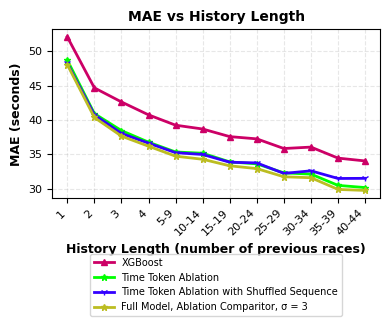

History Length       Naive Mean                                 Riegel Formula                             XGBoost                                    Time Token Ablation                        Time Token Ablation with Shuffled Sequence Full Model, Ablation Comparitor, σ = 3    
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                    nan                                        nan                                        52.10                                      48.73                                      48.23                                      48.07                                     
2                    nan                                        nan                                        44.68                                      40.93        

In [93]:
# Compute mean MAE for each history length bucket
history_mae = defaultdict(dict)
for hist_bucket, model_errors in results_by_history.items():
    for model_name, errors in model_errors.items():
        if len(errors) > 0:
            history_mae[hist_bucket][model_name] = np.mean(errors)

# Sort history buckets
def get_bucket_sort_key(bucket):
    if isinstance(bucket, int):
        return bucket
    return int(bucket.split('-')[0])

sorted_buckets = sorted(history_mae.keys(), key=get_bucket_sort_key)

# Plot
fig, ax = plt.subplots(figsize=(4.0, 5.5))  # Larger single-column format

for model_name in MODELS_PLOT_ORDER:
    if model_name not in results:
        continue
    
    x_vals = []
    y_vals = []
    
    for bucket in sorted_buckets:
        if model_name in history_mae[bucket]:
            x_vals.append(str(bucket))
            y_vals.append(history_mae[bucket][model_name])
    
    if len(x_vals) > 0:
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        ax.plot(x_vals, y_vals, marker=marker, color=color, label=label, linewidth=2, markersize=5)

ax.set_xlabel('History Length (number of previous races)', fontsize=9, fontweight='bold')
ax.set_ylabel('MAE (seconds)', fontsize=9, fontweight='bold')
ax.set_title('MAE vs History Length', fontsize=10, fontweight='bold')
ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, frameon=True, fancybox=True, shadow=False)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', labelsize=7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.25, 1, 1])  # More space at bottom for legend below x-axis label
plt.show()

# Print table with proper column alignment
# Calculate maximum width needed for model labels
max_label_width = max([len(model_labels.get(m, m)) for m in MODELS_PLOT_ORDER if m in results], default=15)
col_width = max(max_label_width, 12)  # At least 12 for numbers, but match label width

# Print header
header = f"{'History Length':<20}"
for model_name in MODELS_PLOT_ORDER:
    if model_name in results:
        label = model_labels.get(model_name, model_name)
        header += f" {label:<{col_width}}"
print(header)
print("-" * len(header))

# Print data rows
for bucket in sorted_buckets:
    row = f"{str(bucket):<20}"
    for model_name in MODELS_PLOT_ORDER:
        if model_name in results:
            mae = history_mae[bucket].get(model_name, np.nan)
            row += f" {mae:<{col_width}.2f}"
    print(row)


## Step 4.5: Normalized MAE vs History Length

MAE normalized by the reference model (MAE / Reference MAE) as a function of history length.

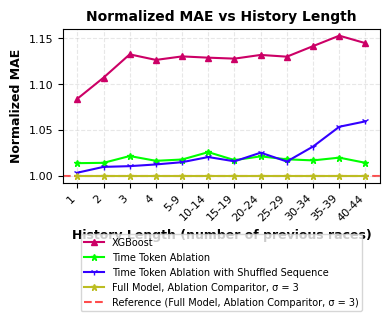


NORMALIZED MAE TABLE (Reference: Full Model, Ablation Comparitor, σ = 3)

History Length       Naive Mean                                 Riegel Formula                             XGBoost                                    Time Token Ablation                        Time Token Ablation with Shuffled Sequence Full Model, Ablation Comparitor, σ = 3    
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                    nan                                        nan                                        1.084                                      1.014                                      1.003                                      1.000                                     
2                    nan                                        nan                     

In [94]:
# Compute normalized MAE (MAE / Reference MAE) for each history length bucket
if REFERENCE_MODEL_FOR_NORMALIZATION is None or REFERENCE_MODEL_FOR_NORMALIZATION not in results:
    print("❌ ERROR: Reference model not available. Please set REFERENCE_MODEL_FOR_NORMALIZATION in cell 2.")
else:
    # Compute mean MAE for each history length bucket (same as Step 4)
    history_mae = defaultdict(dict)
    for hist_bucket, model_errors in results_by_history.items():
        for model_name, errors in model_errors.items():
            if len(errors) > 0:
                history_mae[hist_bucket][model_name] = np.mean(errors)
    
    # Get reference MAE for each bucket
    reference_mae_by_bucket = {}
    for bucket in history_mae.keys():
        if REFERENCE_MODEL_FOR_NORMALIZATION in history_mae[bucket]:
            reference_mae_by_bucket[bucket] = history_mae[bucket][REFERENCE_MODEL_FOR_NORMALIZATION]
        else:
            reference_mae_by_bucket[bucket] = None  # No reference data for this bucket
    
    # Compute normalized MAE (MAE / Reference MAE)
    normalized_history_mae = defaultdict(dict)
    for bucket in history_mae.keys():
        ref_mae = reference_mae_by_bucket[bucket]
        if ref_mae is not None and ref_mae > 0:
            for model_name in history_mae[bucket].keys():
                model_mae = history_mae[bucket][model_name]
                normalized_history_mae[bucket][model_name] = model_mae / ref_mae
    
    # Sort history buckets
    def get_bucket_sort_key(bucket):
        if isinstance(bucket, int):
            return bucket
        return int(bucket.split('-')[0])
    
    sorted_buckets = sorted(normalized_history_mae.keys(), key=get_bucket_sort_key)
    
    # Plot
    fig, ax = plt.subplots(figsize=(4.0, 5.5))  # Larger single-column format
    
    reference_label = model_labels.get(REFERENCE_MODEL_FOR_NORMALIZATION, REFERENCE_MODEL_FOR_NORMALIZATION)
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in results:
            continue
        
        x_vals = []
        y_vals = []
        
        for bucket in sorted_buckets:
            if model_name in normalized_history_mae[bucket]:
                x_vals.append(str(bucket))
                y_vals.append(normalized_history_mae[bucket][model_name])
        
        if len(x_vals) > 0:
            color = model_colors.get(model_name, 'gray')
            marker = model_markers.get(model_name, 'o')
            label = model_labels.get(model_name, model_name)
            ax.plot(x_vals, y_vals, marker=marker, color=color, label=label, linewidth=1.5, markersize=5)
    
    # Add horizontal line at y=1.0 (reference model performance)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
               label=f'Reference ({reference_label})', zorder=0)
    
    ax.set_xlabel('History Length (number of previous races)', fontsize=9, fontweight='bold')
    ax.set_ylabel('Normalized MAE', fontsize=9, fontweight='bold')
    ax.set_title('Normalized MAE vs History Length', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, frameon=True, fancybox=True, shadow=False)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0.25, 1, 1])  # More space at bottom for legend below x-axis label
    plt.show()
    
    # Print table with normalized values
    print("\n" + "="*80)
    print(f"NORMALIZED MAE TABLE (Reference: {reference_label})")
    print("="*80)
    print()
    
    max_label_width = max([len(model_labels.get(m, m)) for m in MODELS_PLOT_ORDER if m in results], default=15)
    col_width = max(max_label_width, 12)
    
    header = f"{'History Length':<20}"
    for model_name in MODELS_PLOT_ORDER:
        if model_name in results:
            label = model_labels.get(model_name, model_name)
            header += f" {label:<{col_width}}"
    print(header)
    print("-" * len(header))
    
    for bucket in sorted_buckets:
        row = f"{str(bucket):<20}"
        for model_name in MODELS_PLOT_ORDER:
            if model_name in results:
                norm_mae = normalized_history_mae[bucket].get(model_name, np.nan)
                row += f" {norm_mae:<{col_width}.3f}"
        print(row)


## Step 4.75: Combined MAE Plots (3 Panels)

All three MAE plots combined into a single figure with 3 vertical panels.

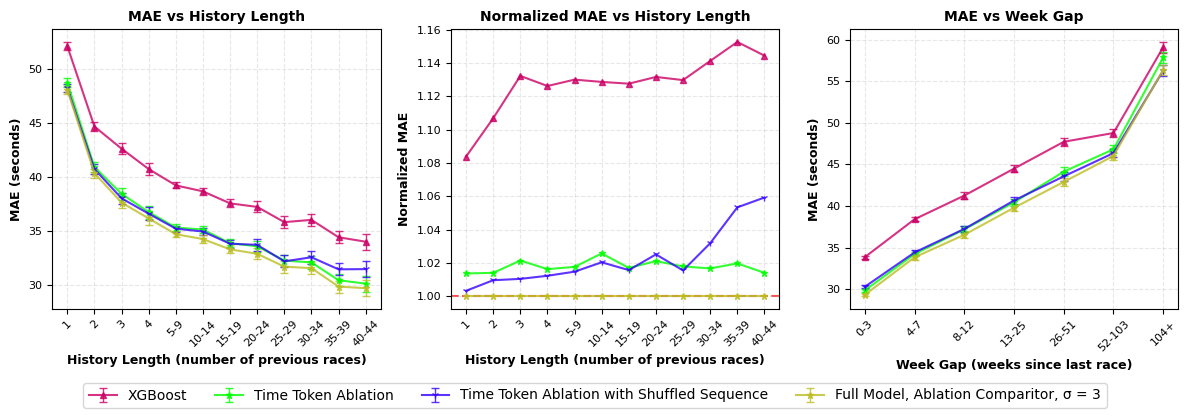

In [102]:
# Create combined figure with 3 subplots (horizontal arrangement)
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))  # 3 panels side by side

# ========================================================================
# Panel 1: MAE vs History Length
# ========================================================================
ax1 = axes[0]

# Compute mean MAE for each history length bucket
history_mae_se = defaultdict(dict)  # Standard error for error bars
history_mae = defaultdict(dict)
for hist_bucket, model_errors in results_by_history.items():
    for model_name, errors in model_errors.items():
        if len(errors) > 0:
            # Compute mean and standard error directly from raw errors
            history_mae[hist_bucket][model_name] = np.mean(errors)
            # Standard error = std / sqrt(n)
            if hist_bucket not in history_mae_se:
                history_mae_se[hist_bucket] = {}
            history_mae_se[hist_bucket][model_name] = np.std(errors, ddof=1) / np.sqrt(len(errors)) if len(errors) > 1 else 0

# Sort history buckets
def get_bucket_sort_key(bucket):
    if isinstance(bucket, int):
        return bucket
    return int(bucket.split('-')[0])

sorted_buckets = sorted(history_mae.keys(), key=get_bucket_sort_key)

for model_name in MODELS_PLOT_ORDER:
    if model_name not in results:
        continue
    
    x_vals = []
    y_vals = []
    
    for bucket in sorted_buckets:
        if model_name in history_mae[bucket]:
            x_vals.append(str(bucket))
            y_vals.append(history_mae[bucket][model_name])
    
    if len(x_vals) > 0:
        for bucket in sorted_buckets:
            if model_name in history_mae[bucket]:
                se = history_mae_se[bucket].get(model_name, 0)
        
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        # Get standard errors for error bars
        y_err = [history_mae_se[bucket].get(model_name, 0) for bucket in sorted_buckets]
        ax1.errorbar(x_vals, y_vals, yerr=y_err, marker=marker, color=color, label=label, 
                     linewidth=1.5, markersize=5, alpha=0.8, capsize=3, capthick=1, elinewidth=1)

ax1.set_xlabel('History Length (number of previous races)', fontsize=9, fontweight='bold')
ax1.set_ylabel('MAE (seconds)', fontsize=9, fontweight='bold')
ax1.set_title('MAE vs History Length', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.tick_params(axis='both', which='minor', labelsize=7)
ax1.tick_params(axis='x', labelrotation=45)

# ========================================================================
# Panel 2: Normalized MAE vs History Length
# ========================================================================
ax2 = axes[1]

if REFERENCE_MODEL_FOR_NORMALIZATION is None or REFERENCE_MODEL_FOR_NORMALIZATION not in results:
    ax2.text(0.5, 0.5, 'Reference model not set.\nPlease set REFERENCE_MODEL_FOR_NORMALIZATION in cell 3.', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Normalized MAE vs History Length (Reference not set)', fontsize=10, fontweight='bold')
else:
    # Get reference MAE for each bucket
    reference_mae_by_bucket = {}
    for bucket in history_mae.keys():
        if REFERENCE_MODEL_FOR_NORMALIZATION in history_mae[bucket]:
            reference_mae_by_bucket[bucket] = history_mae[bucket][REFERENCE_MODEL_FOR_NORMALIZATION]
        else:
            reference_mae_by_bucket[bucket] = None
    
    # Compute normalized MAE and standard error
    normalized_history_mae_se = defaultdict(dict)
    normalized_history_mae = defaultdict(dict)
    for bucket in history_mae.keys():
        ref_mae = reference_mae_by_bucket[bucket]
        if ref_mae is not None and ref_mae > 0:
            for model_name in history_mae[bucket].keys():
                model_mae = history_mae[bucket][model_name]
                # Compute normalized MAE
                normalized_history_mae[bucket][model_name] = model_mae / ref_mae
                
                # Compute standard error using error propagation
                # SE(normalized) = normalized * sqrt((SE_model/MAE_model)^2 + (SE_ref/MAE_ref)^2)
                model_se = history_mae_se[bucket].get(model_name, 0)
                ref_se = history_mae_se[bucket].get(REFERENCE_MODEL_FOR_NORMALIZATION, 0)
                if model_mae > 0 and ref_mae > 0:
                    rel_err_model = (model_se / model_mae) if model_mae > 0 else 0
                    rel_err_ref = (ref_se / ref_mae) if ref_mae > 0 else 0
                    norm_se = (model_mae / ref_mae) * np.sqrt(rel_err_model**2 + rel_err_ref**2)
                    normalized_history_mae_se[bucket][model_name] = norm_se
                else:
                    normalized_history_mae_se[bucket][model_name] = 0
    
    sorted_buckets_norm = sorted(normalized_history_mae.keys(), key=get_bucket_sort_key)
    
    reference_label = model_labels.get(REFERENCE_MODEL_FOR_NORMALIZATION, REFERENCE_MODEL_FOR_NORMALIZATION)
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in results:
            continue
        
        x_vals = []
        y_vals = []
        
        for bucket in sorted_buckets_norm:
            if model_name in normalized_history_mae[bucket]:
                x_vals.append(str(bucket))
                y_vals.append(normalized_history_mae[bucket][model_name])
        
        if len(x_vals) > 0:
            for bucket in sorted_buckets_norm:
                if model_name in normalized_history_mae[bucket]:
                    se = normalized_history_mae_se[bucket].get(model_name, 0)
            
            color = model_colors.get(model_name, 'gray')
            marker = model_markers.get(model_name, 'o')
            label = model_labels.get(model_name, model_name)
            ax2.plot(x_vals, y_vals, marker=marker, color=color, label=label, linewidth=1.5, markersize=5, alpha=0.8)
    
    # Add horizontal line at y=1.0 (reference model performance)
    ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
               label=f'Reference ({reference_label})', zorder=0)
    
    ax2.set_xlabel('History Length (number of previous races)', fontsize=9, fontweight='bold')
    ax2.set_ylabel('Normalized MAE', fontsize=9, fontweight='bold')
    ax2.set_title('Normalized MAE vs History Length', fontsize=10, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.tick_params(axis='both', which='minor', labelsize=7)
    ax2.tick_params(axis='x', labelrotation=45)

# ========================================================================
# Panel 3: MAE vs Week Gap
# ========================================================================
ax3 = axes[2]

# Compute mean MAE for each week delta bucket
week_mae_se = defaultdict(dict)
week_mae = defaultdict(dict)
for week_bucket, model_errors in results_by_week_delta.items():
    for model_name, errors in model_errors.items():
        if len(errors) > 0:
            # Compute mean and standard error directly from raw errors
            week_mae[week_bucket][model_name] = np.mean(errors)
            # Standard error = std / sqrt(n)
            if week_bucket not in week_mae_se:
                week_mae_se[week_bucket] = {}
            week_mae_se[week_bucket][model_name] = np.std(errors, ddof=1) / np.sqrt(len(errors)) if len(errors) > 1 else 0

# Sort week buckets
week_order = ['0-3', '4-7', '8-12', '13-25', '26-51', '52-103', '104+']
sorted_week_buckets = [b for b in week_order if b in week_mae]

for model_name in MODELS_PLOT_ORDER:
    if model_name not in results:
        continue
    
    x_vals = []
    y_vals = []
    
    for bucket in sorted_week_buckets:
        if model_name in week_mae[bucket]:
            x_vals.append(bucket)
            y_vals.append(week_mae[bucket][model_name])
    
    if len(x_vals) > 0:
        for bucket in sorted_week_buckets:
            if model_name in week_mae[bucket]:
                se = week_mae_se[bucket].get(model_name, 0)
        
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        # Get standard errors for error bars
        y_err = [week_mae_se[bucket].get(model_name, 0) for bucket in sorted_week_buckets]
        ax3.errorbar(x_vals, y_vals, yerr=y_err, marker=marker, color=color, label=label, 
                     linewidth=1.5, markersize=5, alpha=0.8, capsize=3, capthick=1, elinewidth=1)

ax3.set_xlabel('Week Gap (weeks since last race)', fontsize=9, fontweight='bold')
ax3.set_ylabel('MAE (seconds)', fontsize=9, fontweight='bold')
ax3.set_title('MAE vs Week Gap', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.tick_params(axis='both', which='major', labelsize=8)
ax3.tick_params(axis='both', which='minor', labelsize=7)
ax3.tick_params(axis='x', labelrotation=45)

# Adjust layout
# Create shared legend for all panels
# Collect handles and labels from first panel
handles, labels = ax1.get_legend_handles_labels()
# Single horizontal legend line under all 3 plots, close to x-axis
fig.legend(handles, labels, loc='lower center', fontsize=10, frameon=True, fancybox=True, shadow=False, bbox_to_anchor=(0.5, -0.05), ncol=len(handles))

plt.tight_layout(rect=[0, 0.02, 1, 1])  # Minimal space at bottom for shared legend
plt.show()


## Step 5: MAE vs Week Gap


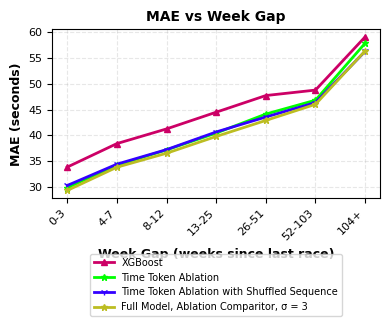

Week Gap             Naive Mean                                 Riegel Formula                             XGBoost                                    Time Token Ablation                        Time Token Ablation with Shuffled Sequence Full Model, Ablation Comparitor, σ = 3    
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0-3                  nan                                        nan                                        33.86                                      29.87                                      30.29                                      29.33                                     
4-7                  nan                                        nan                                        38.41                                      34.23        

In [81]:
# Compute mean MAE for each week delta bucket
week_mae = defaultdict(dict)
for week_bucket, model_errors in results_by_week_delta.items():
    for model_name, errors in model_errors.items():
        if len(errors) > 0:
            week_mae[week_bucket][model_name] = np.mean(errors)

# Sort week buckets
week_order = ['0-3', '4-7', '8-12', '13-25', '26-51', '52-103', '104+']
sorted_week_buckets = [b for b in week_order if b in week_mae]

# Plot
fig, ax = plt.subplots(figsize=(4.0, 5.5))  # Larger single-column format

for model_name in MODELS_PLOT_ORDER:
    if model_name not in results:
        continue
    
    x_vals = []
    y_vals = []
    
    for bucket in sorted_week_buckets:
        if model_name in week_mae[bucket]:
            x_vals.append(bucket)
            y_vals.append(week_mae[bucket][model_name])
    
    if len(x_vals) > 0:
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        ax.plot(x_vals, y_vals, marker=marker, color=color, label=label, linewidth=2, markersize=5)

ax.set_xlabel('Week Gap (weeks since last race)', fontsize=9, fontweight='bold')
ax.set_ylabel('MAE (seconds)', fontsize=9, fontweight='bold')
ax.set_title('MAE vs Week Gap', fontsize=10, fontweight='bold')
ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.30), ncol=1, frameon=True, fancybox=True, shadow=False)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', labelsize=7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.25, 1, 1])  # More space at bottom for legend below x-axis label
plt.show()

# Print table with proper column alignment
# Calculate maximum width needed for model labels
max_label_width = max([len(model_labels.get(m, m)) for m in MODELS_PLOT_ORDER if m in results], default=15)
col_width = max(max_label_width, 12)  # At least 12 for numbers, but match label width

# Print header
header = f"{'Week Gap':<20}"
for model_name in MODELS_PLOT_ORDER:
    if model_name in results:
        label = model_labels.get(model_name, model_name)
        header += f" {label:<{col_width}}"
print(header)
print("-" * len(header))

# Print data rows
for bucket in sorted_week_buckets:
    row = f"{bucket:<20}"
    for model_name in MODELS_PLOT_ORDER:
        if model_name in results:
            mae = week_mae[bucket].get(model_name, np.nan)
            row += f" {mae:<{col_width}.2f}"
    print(row)


## Step 6: Calibration Analysis - Histogram and Q-Q Plots


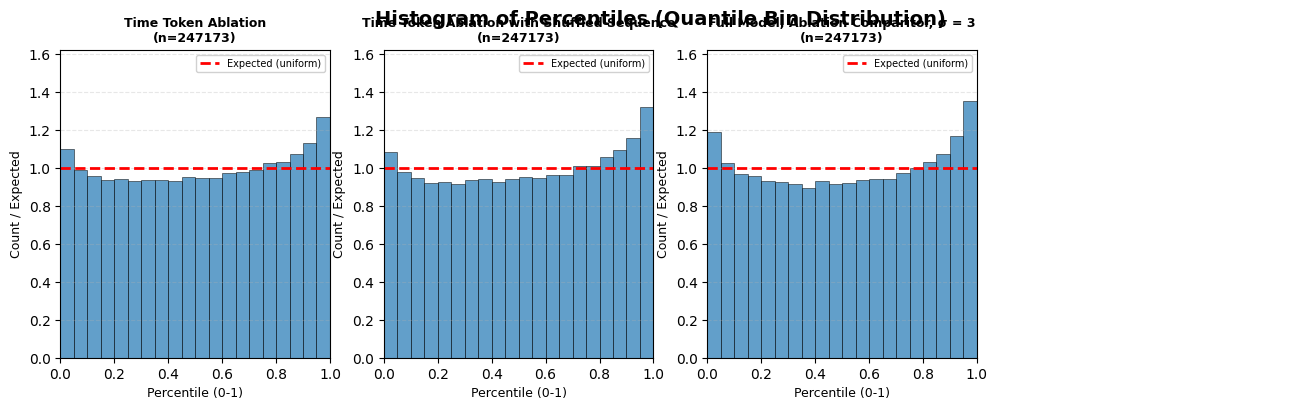

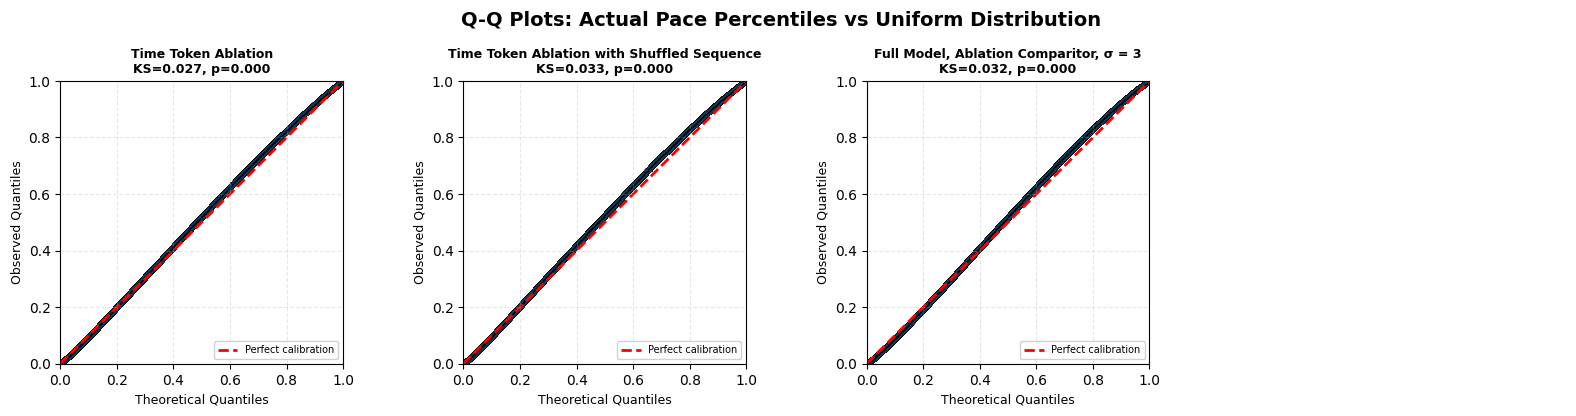


KS STATISTICS SUMMARY
Model                                         KS Statistic    P-value         Calibrated? 
--------------------------------------------------------------------------------
Time Token Ablation                           0.026748        4.592235e-154   No          
Full Model, Ablation Comparitor, σ = 3        0.031797        1.500431e-217   No          
Time Token Ablation with Shuffled Sequence    0.033033        9.239408e-235   No          
--------------------------------------------------------------------------------
Note: Lower KS statistic is better (0 = perfect calibration)
      P-value > 0.05 indicates well-calibrated (cannot reject uniformity)


CALIBRATION CURVE PLOT

Found calibration data for 3 models: Time Token Ablation, Time Token Ablation with Shuffled Sequence, Full Model, Ablation Comparitor, σ = 3

✓ Time Token Ablation: 50000 points, 10 bins
  Mean predicted probability: 0.601
  Mean observed frequency: 0.598

✓ Time Token Ablation with Shuffl

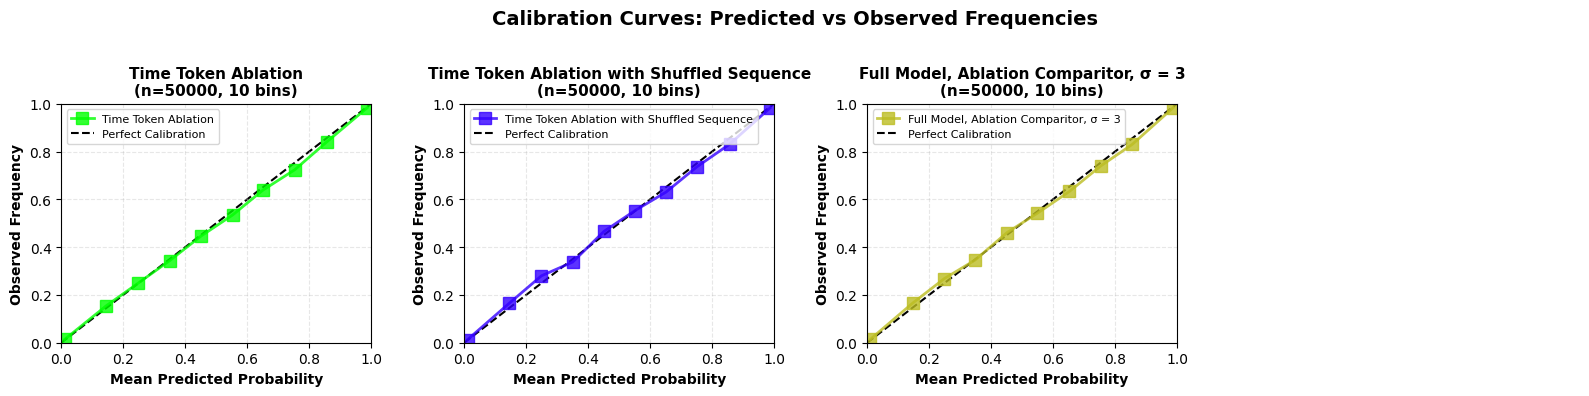


Calibration Summary:
--------------------------------------------------------------------------------
Time Token Ablation:
  Total predictions: 50000
  Mean predicted probability: 0.601
  Mean observed frequency: 0.598

Time Token Ablation with Shuffled Sequence:
  Total predictions: 50000
  Mean predicted probability: 0.597
  Mean observed frequency: 0.594

Full Model, Ablation Comparitor, σ = 3:
  Total predictions: 50000
  Mean predicted probability: 0.596
  Mean observed frequency: 0.594

Interpretation:
  - Points on the diagonal (dashed line) = perfect calibration
  - Points above diagonal = model overconfident (predicts too high)
  - Points below diagonal = model underconfident (predicts too low)


In [82]:
# Create histogram and Q-Q plots for each model
# Use MODELS_PLOT_ORDER to ensure all selected models are included, but only plot those with percentile data
models_to_plot = [m for m in MODELS_PLOT_ORDER if m in percentiles_by_model]
num_models = len(models_to_plot)

if num_models == 0:
    print("⚠️  No models with percentile data to plot")
else:
    cols = 4
    rows = (num_models + cols - 1) // cols

    fig_hist, axes_hist = plt.subplots(rows, cols, figsize=(16, 4*rows))
    fig_qq, axes_qq = plt.subplots(rows, cols, figsize=(16, 4*rows))

if rows == 1:
    axes_hist = axes_hist.reshape(1, -1)
    axes_qq = axes_qq.reshape(1, -1)

axes_hist = axes_hist.flatten()
axes_qq = axes_qq.flatten()

# First pass: compute maximum ratio (count/expected) across all histograms for consistent y-axis scaling
# We'll normalize by expected uniform value to show ratios
max_ratio = 0
bin_edges = np.linspace(0, 1, 21)  # 20 bins (0.05 spacing) - same for all models
for model_name, percentiles in percentiles_by_model.items():
    if len(percentiles) == 0:
        continue
    percentiles_fraction = np.array(percentiles) / 100.0
    counts, _ = np.histogram(percentiles_fraction, bins=bin_edges)
    expected_count = len(percentiles) / 20  # 20 bins, uniform distribution
    if expected_count > 0:
        ratios = counts / expected_count
        max_ratio = max(max_ratio, ratios.max())

# Add some padding (20% above max ratio, but at least 1.5)
y_max = max(max_ratio * 1.2, 1.5) if max_ratio > 0 else 1.5

# Second pass: plot histograms with consistent y-axis
for idx, (model_name, percentiles) in enumerate(percentiles_by_model.items()):
    if idx >= len(axes_hist):
        break
    
    if len(percentiles) == 0:
        axes_hist[idx].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes_hist[idx].transAxes)
        axes_qq[idx].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes_qq[idx].transAxes)
        continue
    
    # Histogram - use proper bar chart with normalized y-axis (ratio to expected)
    percentiles_fraction = np.array(percentiles) / 100.0
    counts, edges = np.histogram(percentiles_fraction, bins=bin_edges)
    
    # Calculate expected count and normalize to ratios
    expected_count = len(percentiles) / 20  # 20 bins, uniform distribution
    ratios = counts / expected_count if expected_count > 0 else counts
    
    # Calculate bin centers and widths for bar chart
    # edges has length 21 (0, 0.05, 0.10, ..., 1.0), so we have 20 bins
    bin_centers = (edges[:-1] + edges[1:]) / 2.0  # Centers of each bin
    bin_width = edges[1] - edges[0]  # Width of each bin (should be 0.05)
    
    # Create bar chart - use left edges for positioning, width for bar size
    # Plot ratios instead of raw counts
    axes_hist[idx].bar(edges[:-1], ratios, width=bin_width, align='edge', 
                       alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add expected uniform distribution line at 1.0 (ratio = 1.0 means exactly expected)
    axes_hist[idx].axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Expected (uniform)')
    axes_hist[idx].set_xlabel('Percentile (0-1)', fontsize=9)
    axes_hist[idx].set_ylabel('Count / Expected', fontsize=9)
    axes_hist[idx].set_title(f"{model_labels.get(model_name, model_name)}\n(n={len(percentiles)})", fontsize=9, fontweight='bold')
    axes_hist[idx].set_ylim(0, y_max)  # Set consistent y-axis scale (ratios)
    axes_hist[idx].set_xlim(0, 1)  # Ensure x-axis covers full range
    axes_hist[idx].grid(True, alpha=0.3, linestyle='--', axis='y')
    # Place legend inside plot area at upper right to avoid overlap
    axes_hist[idx].legend(fontsize=7, loc='upper right', framealpha=0.9)
    
    # Q-Q plot
    sorted_percentiles = np.sort(percentiles_fraction)
    n = len(sorted_percentiles)
    theoretical_quantiles = np.linspace(0, 1, n)
    
    # Compute KS statistic
    ks_stat, ks_pval = kstest(percentiles_fraction, 'uniform')
    
    axes_qq[idx].scatter(theoretical_quantiles, sorted_percentiles, alpha=0.5, s=10, edgecolors='black', linewidths=0.3)
    axes_qq[idx].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration', zorder=1)
    axes_qq[idx].set_xlabel('Theoretical Quantiles', fontsize=9)
    axes_qq[idx].set_ylabel('Observed Quantiles', fontsize=9)
    axes_qq[idx].set_title(f"{model_labels.get(model_name, model_name)}\nKS={ks_stat:.3f}, p={ks_pval:.3f}", fontsize=9, fontweight='bold')
    axes_qq[idx].grid(True, alpha=0.3, linestyle='--')
    axes_qq[idx].set_xlim(0, 1)
    axes_qq[idx].set_ylim(0, 1)
    axes_qq[idx].set_aspect('equal')
    # Place legend inside plot area at lower right to avoid overlap
    axes_qq[idx].legend(fontsize=7, loc='lower right', framealpha=0.9)

# Hide unused subplots
for idx in range(len(percentiles_by_model), len(axes_hist)):
    axes_hist[idx].axis('off')
    axes_qq[idx].axis('off')

fig_hist.suptitle('Histogram of Percentiles (Quantile Bin Distribution)', fontsize=14, fontweight='bold')
fig_qq.suptitle('Q-Q Plots: Actual Pace Percentiles vs Uniform Distribution', fontsize=14, fontweight='bold')

# Adjust layout to prevent legend overlap with x-axis labels
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at top for suptitle
plt.subplots_adjust(hspace=0.4, wspace=0.3)  # Add more vertical and horizontal spacing
plt.show()

# Print KS statistics summary table
print("\n" + "="*80)
print("KS STATISTICS SUMMARY")
print("="*80)
print(f"{'Model':<45} {'KS Statistic':<15} {'P-value':<15} {'Calibrated?':<12}")
print("-"*80)

# Collect KS statistics for all models
ks_summary = []
for model_name in models_to_plot:
    if model_name not in percentiles_by_model:
        continue
    percentiles = percentiles_by_model[model_name]
    if len(percentiles) == 0:
        continue
    
    # Compute KS statistic
    percentiles_fraction = np.array(percentiles) / 100.0
    ks_stat, ks_pval = kstest(percentiles_fraction, 'uniform')
    
    # Determine if calibrated (p > 0.05 means cannot reject uniformity)
    calibrated = "Yes" if ks_pval > 0.05 else "No"
    
    display_label = model_labels.get(model_name, model_name)
    ks_summary.append({
        'model': display_label,
        'ks_stat': ks_stat,
        'p_value': ks_pval,
        'calibrated': calibrated
    })

# Sort by KS statistic (lower is better)
ks_summary.sort(key=lambda x: x['ks_stat'])

# Print table
for item in ks_summary:
    print(f"{item['model']:<45} {item['ks_stat']:<15.6f} {item['p_value']:<15.6e} {item['calibrated']:<12}")

print("-"*80)
print("Note: Lower KS statistic is better (0 = perfect calibration)")
print("      P-value > 0.05 indicates well-calibrated (cannot reject uniformity)")
print("="*80)
print()

# Calibration Curve Plot (if calibration data is available)
# Use the calibration_data variable that was loaded/merged earlier
if calibration_data and len(calibration_data) > 0:
    print("\n" + "="*80)
    print("CALIBRATION CURVE PLOT")
    print("="*80)
    print()
    
    
    # Iterate through all models that have calibration data, respecting MODELS_PLOT_ORDER when possible
    # First, get all models with calibration data
    models_with_cal_data = set(calibration_data.keys())
    
    # Create ordered list: models in MODELS_PLOT_ORDER first, then others
    ordered_models = []
    for model_name in MODELS_PLOT_ORDER:
        if model_name in models_with_cal_data:
            ordered_models.append(model_name)
    # Add any remaining models not in MODELS_PLOT_ORDER
    for model_name in sorted(models_with_cal_data):
        if model_name not in ordered_models:
            ordered_models.append(model_name)
    
    print(f"Found calibration data for {len(ordered_models)} models: {', '.join([model_labels.get(m, m) for m in ordered_models])}")
    print()
    
    # Create grid of calibration plots (similar to Q-Q plots)
    num_models_cal = len(ordered_models)
    cols_cal = 4
    rows_cal = (num_models_cal + cols_cal - 1) // cols_cal
    
    fig_cal, axes_cal = plt.subplots(rows_cal, cols_cal, figsize=(16, 4*rows_cal))
    
    if rows_cal == 1:
        axes_cal = axes_cal.reshape(1, -1) if cols_cal > 1 else axes_cal.reshape(1, 1)
    
    axes_cal = axes_cal.flatten()
    
    # Plot calibration curve for each model
    for idx, model_name in enumerate(ordered_models):
        ax = axes_cal[idx]
        
        predicted_probs = calibration_data[model_name]['predicted_probs']
        actual_outcomes = calibration_data[model_name]['actual_outcomes']
        
        # Check if we have both 0 and 1 in actual_outcomes
        unique_outcomes = np.unique(actual_outcomes)
        if len(unique_outcomes) < 2:
            print(f"⚠️  Warning: {model_labels.get(model_name, model_name)} - Skipping calibration curve (only one outcome value: {unique_outcomes})")
            ax.axis('off')
            continue
        
        # Determine number of bins based on data size
        n_data_points = len(predicted_probs)
        n_bins = min(10, max(3, n_data_points // 100))  # At least 3 bins, at most 10
        
        try:
            # Clip predicted_probs to [0, 1] range (required by calibration_curve)
            predicted_probs_clipped = np.clip(predicted_probs, 0.0, 1.0)
            fraction_of_positives, mean_predicted_value = calibration_curve(
                actual_outcomes, predicted_probs_clipped, n_bins=n_bins, strategy='uniform', pos_label=1
            )
            
            color = model_colors.get(model_name, 'gray')
            label = model_labels.get(model_name, model_name)
            
            # Plot calibration curve
            ax.plot(mean_predicted_value, fraction_of_positives, 's-', markersize=8, 
                    linewidth=2, label=label, color=color, alpha=0.8)
            
            # Plot perfect calibration line
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration', zorder=1)
            
            ax.set_xlabel('Mean Predicted Probability', fontsize=10, fontweight='bold')
            ax.set_ylabel('Observed Frequency', fontsize=10, fontweight='bold')
            ax.set_title(f'{label}\n(n={n_data_points}, {n_bins} bins)', fontsize=11, fontweight='bold')
            ax.legend(fontsize=8, loc='upper left')
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            
            print(f"✓ {label}: {n_data_points} points, {n_bins} bins")
            
            # Print summary statistics for this model
            mean_pred = np.mean(predicted_probs_clipped)
            mean_obs = np.mean(actual_outcomes)
            print(f"  Mean predicted probability: {mean_pred:.3f}")
            print(f"  Mean observed frequency: {mean_obs:.3f}")
            print()
            
        except Exception as e:
            print(f"⚠️  Warning: {model_labels.get(model_name, model_name)} - Error creating calibration curve: {e}")
            import traceback
            print(f"   Traceback: {traceback.format_exc()}")
            ax.axis('off')
            continue
    
    # Hide unused subplots
    for idx in range(num_models_cal, len(axes_cal)):
        axes_cal[idx].axis('off')
    
    fig_cal.suptitle('Calibration Curves: Predicted vs Observed Frequencies', fontsize=14, fontweight='bold')
    
    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at top for suptitle
    plt.subplots_adjust(hspace=0.4, wspace=0.3)  # Add more vertical and horizontal spacing
    plt.show()
    
    # Print summary statistics
    print("\nCalibration Summary:")
    print("-" * 80)
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in calibration_data:
            continue
        
        predicted_probs = calibration_data[model_name]['predicted_probs']
        actual_outcomes = calibration_data[model_name]['actual_outcomes']
        
        print(f"{model_labels.get(model_name, model_name)}:")
        print(f"  Total predictions: {len(predicted_probs)}")
        print(f"  Mean predicted probability: {predicted_probs.mean():.3f}")
        print(f"  Mean observed frequency: {actual_outcomes.mean():.3f}")
        print()
    
    print("Interpretation:")
    print("  - Points on the diagonal (dashed line) = perfect calibration")
    print("  - Points above diagonal = model overconfident (predicts too high)")
    print("  - Points below diagonal = model underconfident (predicts too low)")
    print("="*80)
else:
    print("\n⚠️  No calibration curve data found.")
    print("   The calibration curve requires a second pass through the data.")
    print("   This feature was added in a recent version of evaluate_models.py")


## Step 7: 5 Example Distributions Plot

Show individual example predictions with density plots for all models overlaid.


In [83]:
# Check if we have example predictions
if len(example_predictions) == 0:
    print("⚠️  No example predictions found in data.")
    print("   The '5 Example Distributions' plot requires example predictions to be saved.")
    print("   This feature was added in a recent version of evaluate_models.py")
else:
    from scipy.interpolate import PchipInterpolator
    
    def format_seconds_to_mmss(seconds):
        """Convert seconds to MM:SS format."""
        minutes = int(seconds // 60)
        secs = int(seconds % 60)
        return f"{minutes}:{secs:02d}"
    
    def format_distance_token(distance_token):
        """Format distance token to readable string."""
        if not distance_token:
            return "Unknown Distance"
        if distance_token.startswith('distance_name_token_'):
            distance = distance_token.replace('distance_name_token_', '')
            distance = distance.replace('_', ' ').title()
            return distance
        return distance_token
    
    def format_week_delta(week_delta_token):
        """Extract and format week delta from token like 'week_delta_140'."""
        if not week_delta_token:
            return "Unknown"
        if isinstance(week_delta_token, str) and week_delta_token.startswith('week_delta_'):
            try:
                weeks = int(week_delta_token.replace('week_delta_', ''))
                return f"{weeks}w"
            except ValueError:
                return week_delta_token
        return str(week_delta_token)
    
    def create_density_plot_multi_models(ex, predictions_by_model, example_num=0, ax=None):
        """Create a density plot comparing all models on the same plot."""
        actual_pace = float(ex.actual_pace_seconds)
        
        # Extract race distance and week delta
        race_distance = "Unknown Distance"
        week_delta_str = "Unknown"
        if ex.raw_pace_data and len(ex.raw_pace_data) > 0:
            last_race_data = ex.raw_pace_data[-1]
            if isinstance(last_race_data, tuple) and len(last_race_data) > 0:
                race_distance = format_distance_token(last_race_data[0])
            
            if len(ex.raw_pace_data) >= 2:
                prev_race_data = ex.raw_pace_data[-2]
                if isinstance(prev_race_data, tuple) and len(prev_race_data) > 1:
                    week_delta_str = format_week_delta(prev_race_data[1])
        
        actual_pace_mmss = format_seconds_to_mmss(actual_pace)
        
        # Create or use provided axis
        if ax is None:
            plt.figure(figsize=(14, 7))
            ax = plt.gca()
        
        # Calculate history length
        seq_len = len(ex.unpadded_example_sequence)
        block_stride = 11
        num_races = seq_len // block_stride
        num_prev_races = num_races - 1
        
        # Plot each model's distribution
        for model_name in MODELS_PLOT_ORDER:
            if model_name not in predictions_by_model:
                continue
            
            pred_data = predictions_by_model[model_name]
            probs = pred_data['probabilities']
            pace_bins = pred_data['pace_bins']
            
            # Get pace values and widths
            pace_values = np.array([b['median'] for b in pace_bins])
            pace_widths = np.array([b['end'] - b['start'] for b in pace_bins])
            
            # Normalize probabilities
            probs_normalized = probs / probs.sum() if probs.sum() > 0 else probs
            
            # Compute density (probability / width)
            density = probs_normalized / pace_widths
            density = np.maximum(0, density)  # Ensure non-negative
            
            # Ensure pace_values is strictly increasing for PCHIP interpolation
            # Sort by pace_values and remove duplicates
            sort_indices = np.argsort(pace_values)
            pace_values_sorted = pace_values[sort_indices]
            density_sorted = density[sort_indices]
            
            # Remove duplicates by keeping first occurrence
            # Use a small tolerance for floating point comparison
            unique_indices = []
            seen_values = set()
            for i, val in enumerate(pace_values_sorted):
                val_rounded = round(val, 6)
                if val_rounded not in seen_values:
                    unique_indices.append(i)
                    seen_values.add(val_rounded)
            
            pace_values_unique = pace_values_sorted[unique_indices]
            density_unique = density_sorted[unique_indices]
            
            # If we still have non-increasing values (shouldn't happen, but be safe),
            # enforce strict monotonicity by adding tiny increments
            for i in range(1, len(pace_values_unique)):
                if pace_values_unique[i] <= pace_values_unique[i-1]:
                    pace_values_unique[i] = pace_values_unique[i-1] + 1e-6
            
            # Create fine-grained pace grid for interpolation
            pace_min = pace_values_unique.min()
            pace_max = pace_values_unique.max()
            pace_fine = np.linspace(pace_min, pace_max, 1000)
            
            # Interpolate density using PCHIP (now with strictly increasing x values)
            interpolator = PchipInterpolator(pace_values_unique, density_unique, extrapolate=False)
            density_interp = interpolator(pace_fine)
            density_interp = np.maximum(0, density_interp)  # Ensure non-negative
            
            # Normalize interpolated density
            integral = np.trapz(density_interp, pace_fine)
            if integral > 0:
                density_interp = density_interp / integral
            
            # Plot interpolated density
            color = model_colors.get(model_name, 'gray')
            label = model_labels.get(model_name, model_name)
            ax.plot(pace_fine, density_interp, color=color, linewidth=2, label=label, alpha=0.8)
        
        # Add vertical line for actual pace
        ax.axvline(actual_pace, color='black', linestyle='--', linewidth=2, label='Actual Pace', zorder=10)
        
        ax.set_xlabel('Pace (seconds)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Density', fontsize=10, fontweight='bold')
        ax.set_title(f"#{example_num}: {race_distance} | {actual_pace_mmss} | {week_delta_str} | {num_prev_races} prev", 
                    fontsize=10, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_ylim(0, None)
    
    # Create plot
    n_examples = len(example_predictions)
    n_cols = min(4, n_examples)
    n_rows = (n_examples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    fig.suptitle("All Transformer Models - Example Distributions (different runners)", 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Flatten axes array
    if n_examples == 1:
        axes_flat = [axes]
    elif n_rows == 1:
        axes_flat = [axes] if n_cols == 1 else list(axes)
    else:
        axes_flat = list(axes.flatten())
    
    # Plot each example
    for idx, ex_pred in enumerate(example_predictions):
        if idx < len(axes_flat):
            ax = axes_flat[idx]
            ex = ex_pred['example']
            predictions_by_model = ex_pred['predictions_by_model']
            create_density_plot_multi_models(ex, predictions_by_model, example_num=idx+1, ax=ax)
    
    # Hide unused subplots
    for idx in range(n_examples, len(axes_flat)):
        axes_flat[idx].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    print(f"✓ Plotted {len(example_predictions)} example distributions")

⚠️  No example predictions found in data.
   The '5 Example Distributions' plot requires example predictions to be saved.
   This feature was added in a recent version of evaluate_models.py


## Step 8: Calibration Analysis by Pace Deciles


CALIBRATION ANALYSIS BY PACE DECILES
Analyzing 3 models


MODEL 1/3: Time Token Ablation (model_ablation)

Using data from file: evaluation_results/evaluation_results_250000_ablations_cluster.pickle
XGBoost indices range: 0 to 247173 (out of 247173 total)
✓ Collected 247173 examples
  Actual pace range: 0.0s to 3577.0s

Decile boundaries:
  Decile 1: 0-24716 examples, pace range: 0.0s - 426.0s
  Decile 2: 24717-49433 examples, pace range: 426.0s - 466.0s
  Decile 3: 49434-74150 examples, pace range: 466.0s - 496.0s
  Decile 4: 74151-98867 examples, pace range: 496.0s - 523.0s
  Decile 5: 98868-123584 examples, pace range: 523.0s - 549.0s
  Decile 6: 123585-148301 examples, pace range: 549.0s - 578.0s
  Decile 7: 148302-173018 examples, pace range: 578.0s - 611.0s
  Decile 8: 173019-197735 examples, pace range: 611.0s - 655.0s
  Decile 9: 197736-222452 examples, pace range: 655.0s - 730.0s
  Decile 10: 222453-247172 examples, pace range: 730.0s - 3577.0s


AVERAGE PREDICTED QUANTILE VS 

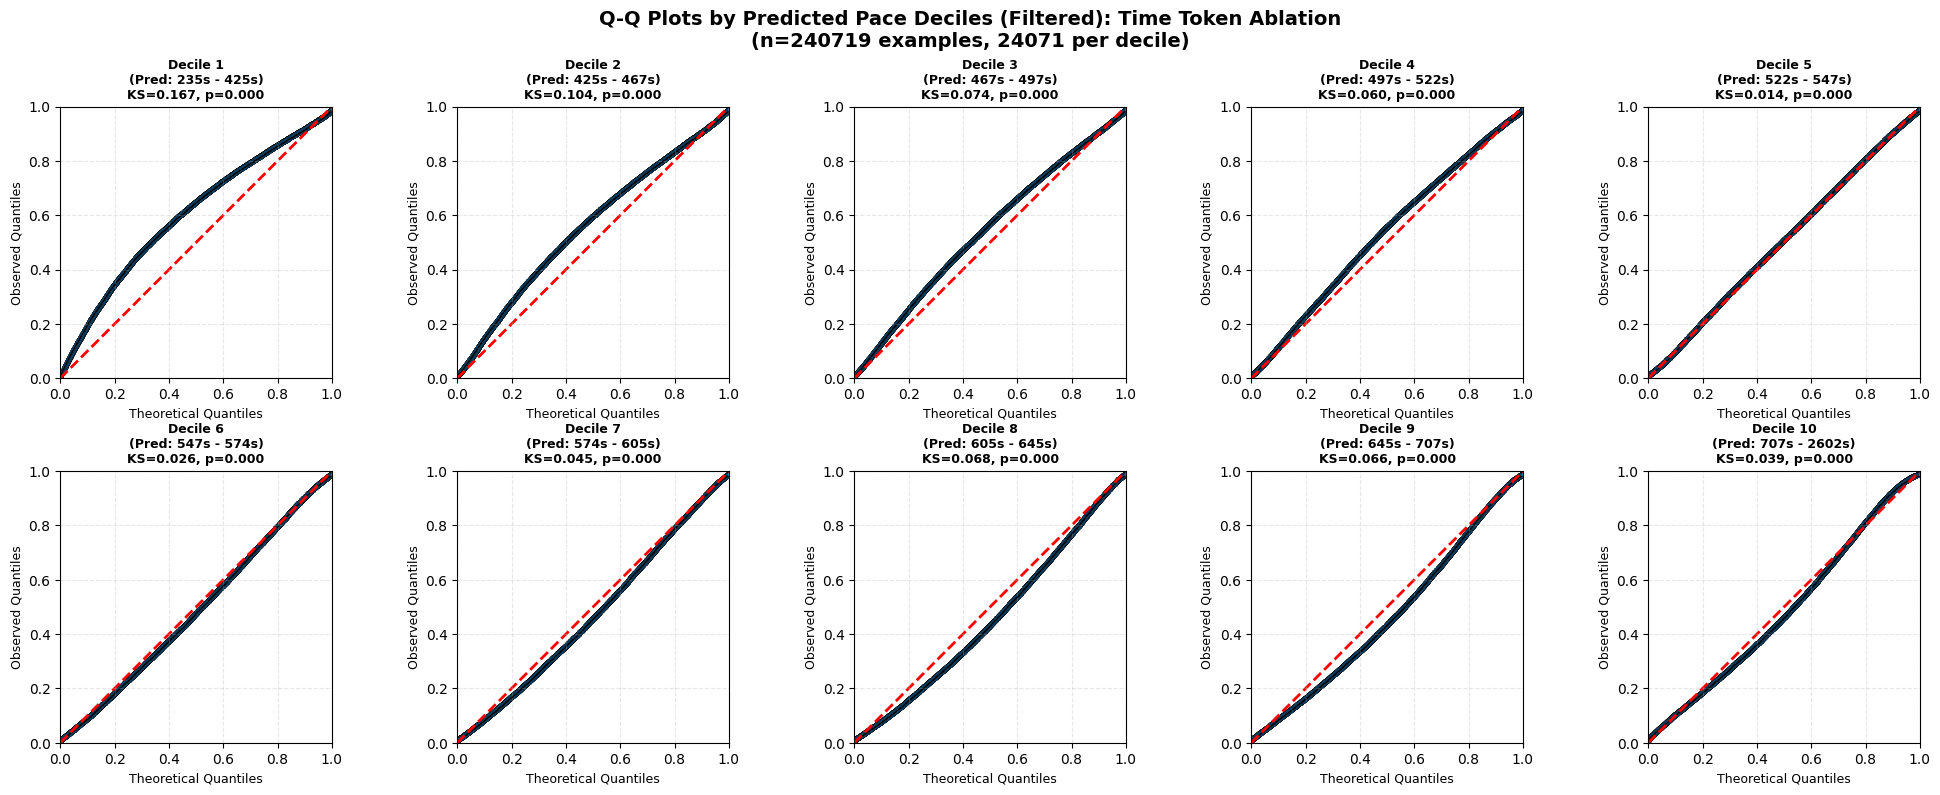

  Decile 1: 23900 ties in actual, 2 ties in predicted
  Decile 2: 24029 ties in actual, 3 ties in predicted
  Decile 3: 24040 ties in actual, 6 ties in predicted
  Decile 4: 24044 ties in actual, 8 ties in predicted
  Decile 5: 24044 ties in actual, 9 ties in predicted
  Decile 6: 24042 ties in actual, 6 ties in predicted
  Decile 7: 24038 ties in actual, 8 ties in predicted
  Decile 8: 24027 ties in actual, 9 ties in predicted
  Decile 9: 23999 ties in actual, 7 ties in predicted
  Decile 10: 23442 ties in actual, 13 ties in predicted


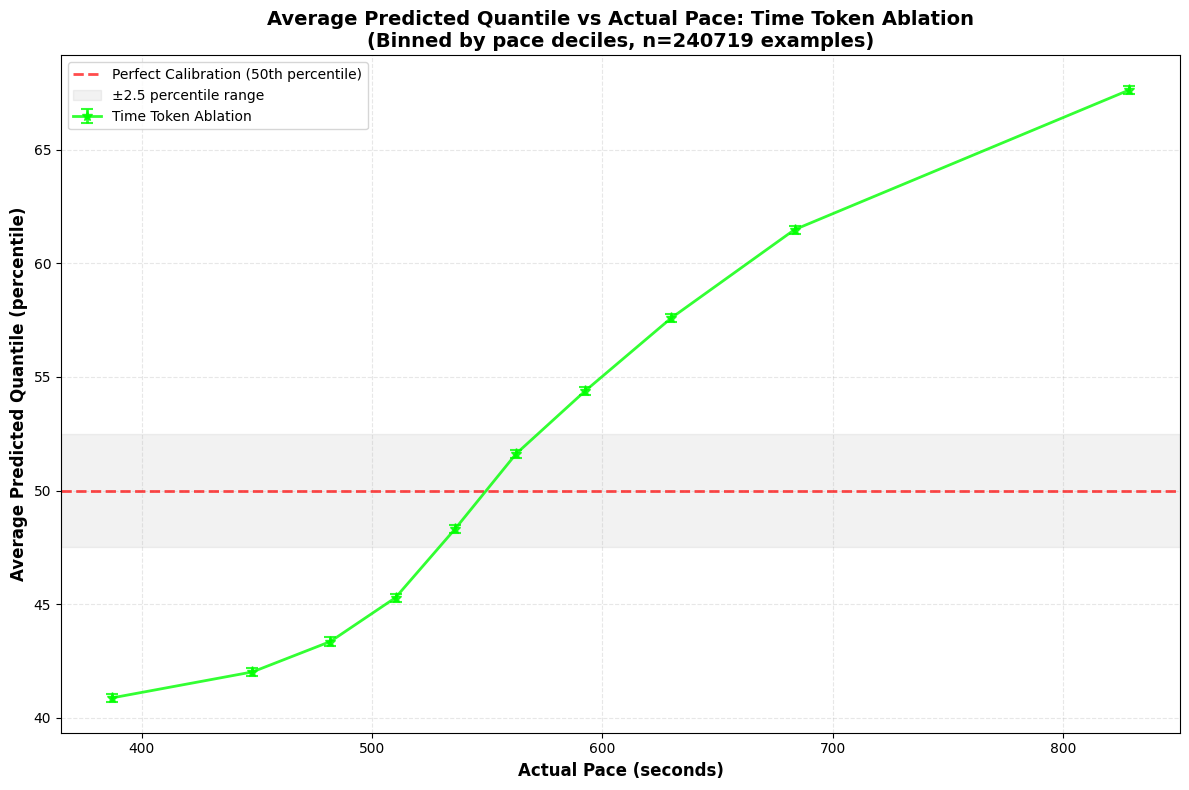

Summary Statistics:
  Overall mean percentile: 51.25
  Overall std percentile: 28.97
  Deviation from 50: 1.25

By Pace Decile:
Decile   Pace Range                N      Mean %ile    Std %ile     SEM       
--------------------------------------------------------------------------------
1        246s - 426s      24071  40.87        27.21        0.18      
2        426s - 467s      24071  42.02        27.86        0.18      
3        467s - 497s      24071  43.35        27.71        0.18      
4        497s - 523s      24071  45.29        27.72        0.18      
5        523s - 549s      24071  48.31        27.79        0.18      
6        549s - 577s      24071  51.61        28.24        0.18      
7        577s - 609s      24071  54.37        28.58        0.18      
8        609s - 652s      24071  57.58        27.99        0.18      
9        652s - 723s      24071  61.48        27.17        0.18      
10       723s - 3037s      24080  67.62        26.61        0.17      

CALIBRATIO

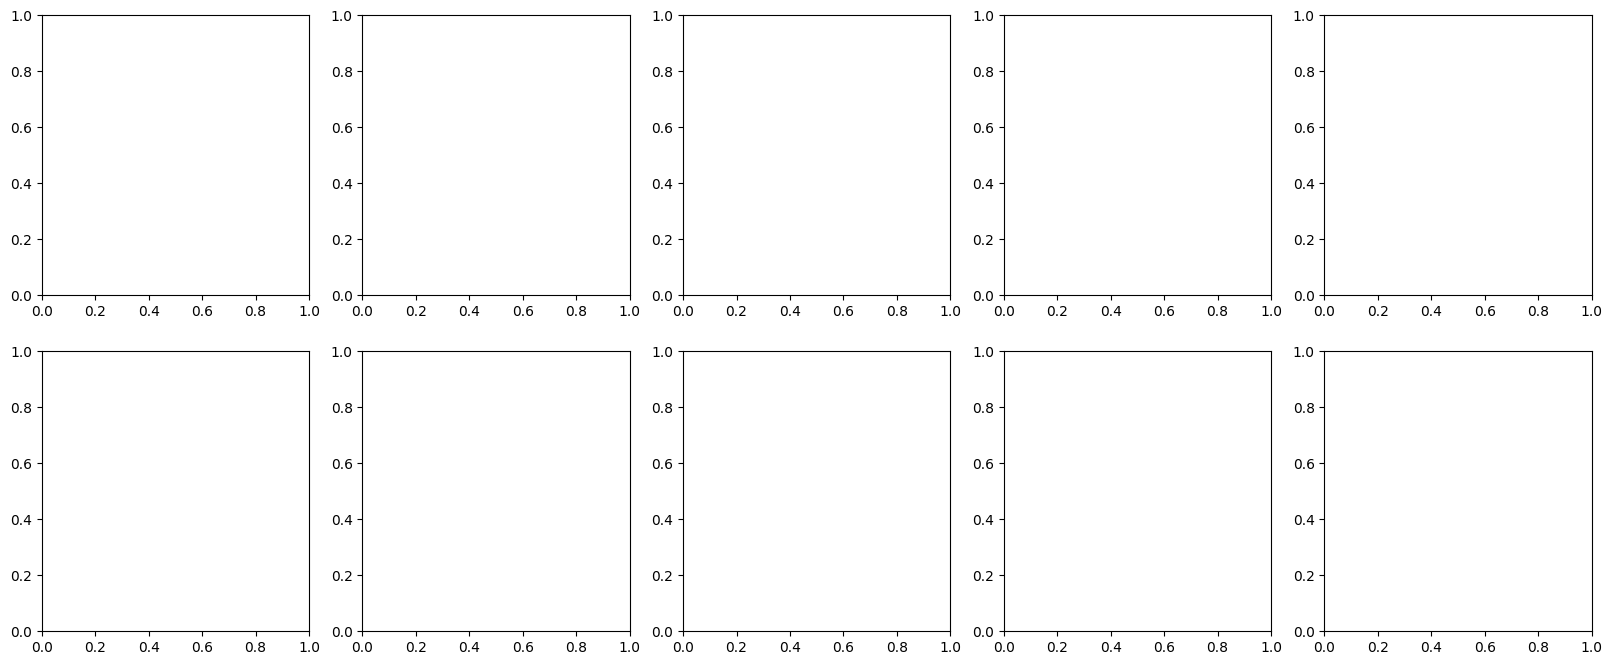

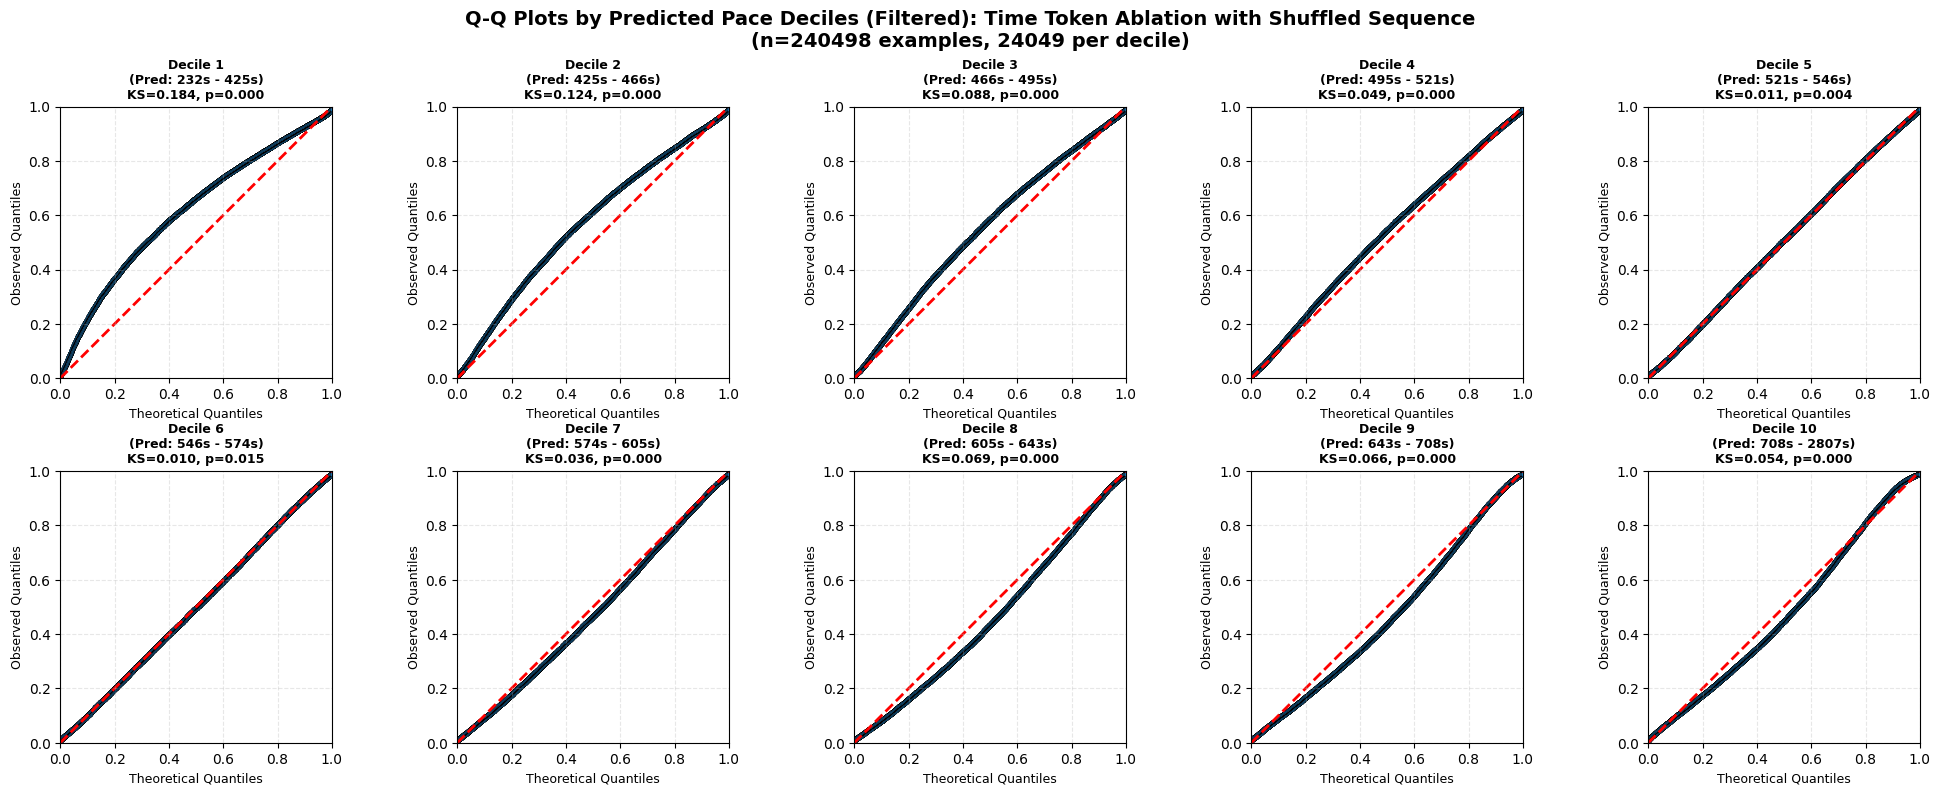

  Decile 1: 23878 ties in actual, 0 ties in predicted
  Decile 2: 24007 ties in actual, 1 ties in predicted
  Decile 3: 24018 ties in actual, 1 ties in predicted
  Decile 4: 24022 ties in actual, 0 ties in predicted
  Decile 5: 24022 ties in actual, 0 ties in predicted
  Decile 6: 24020 ties in actual, 0 ties in predicted
  Decile 7: 24016 ties in actual, 2 ties in predicted
  Decile 8: 24005 ties in actual, 3 ties in predicted
  Decile 9: 23977 ties in actual, 1 ties in predicted
  Decile 10: 23421 ties in actual, 1 ties in predicted


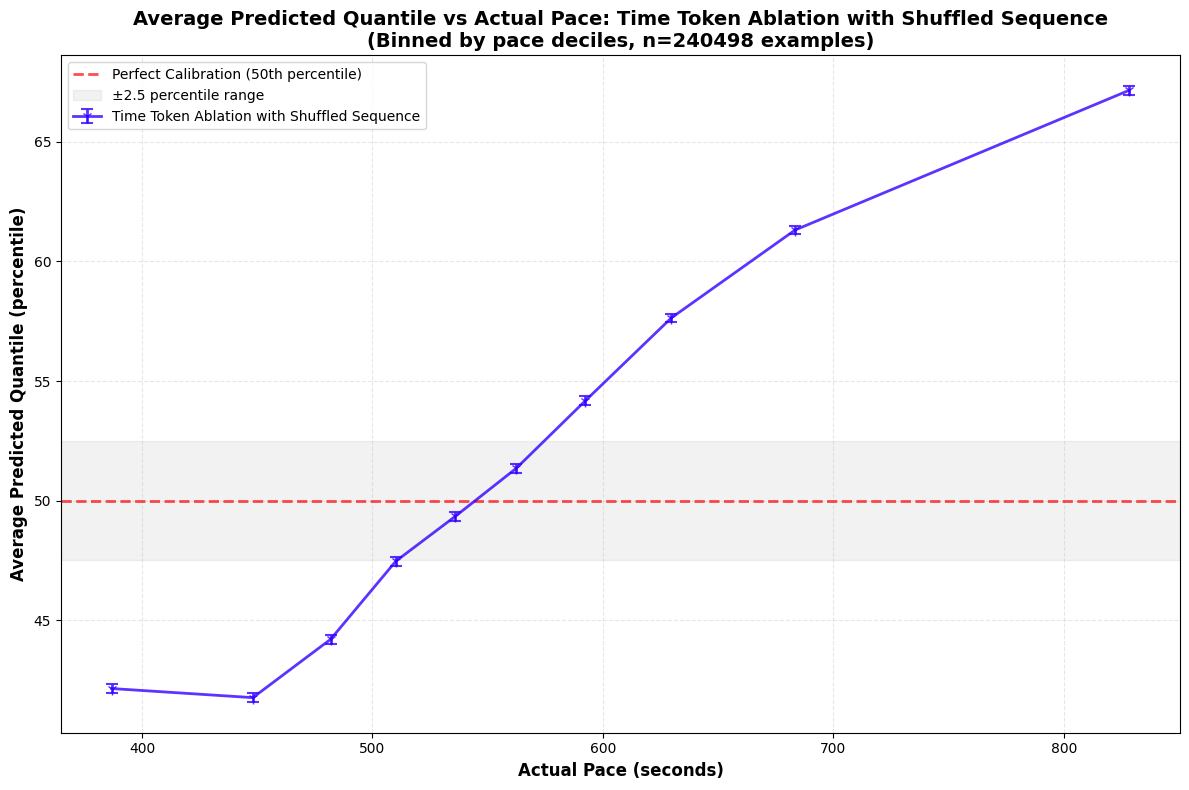

Summary Statistics:
  Overall mean percentile: 51.66
  Overall std percentile: 29.01
  Deviation from 50: 1.66

By Pace Decile:
Decile   Pace Range                N      Mean %ile    Std %ile     SEM       
--------------------------------------------------------------------------------
1        246s - 426s      24049  42.14        27.69        0.18      
2        426s - 467s      24049  41.76        27.85        0.18      
3        467s - 497s      24049  44.21        27.85        0.18      
4        497s - 523s      24049  47.47        27.89        0.18      
5        523s - 549s      24049  49.35        28.52        0.18      
6        549s - 577s      24049  51.35        28.25        0.18      
7        577s - 609s      24049  54.17        28.09        0.18      
8        609s - 652s      24049  57.65        27.75        0.18      
9        652s - 723s      24049  61.32        27.76        0.18      
10       723s - 3288s      24057  67.16        27.18        0.18      

CALIBRATIO

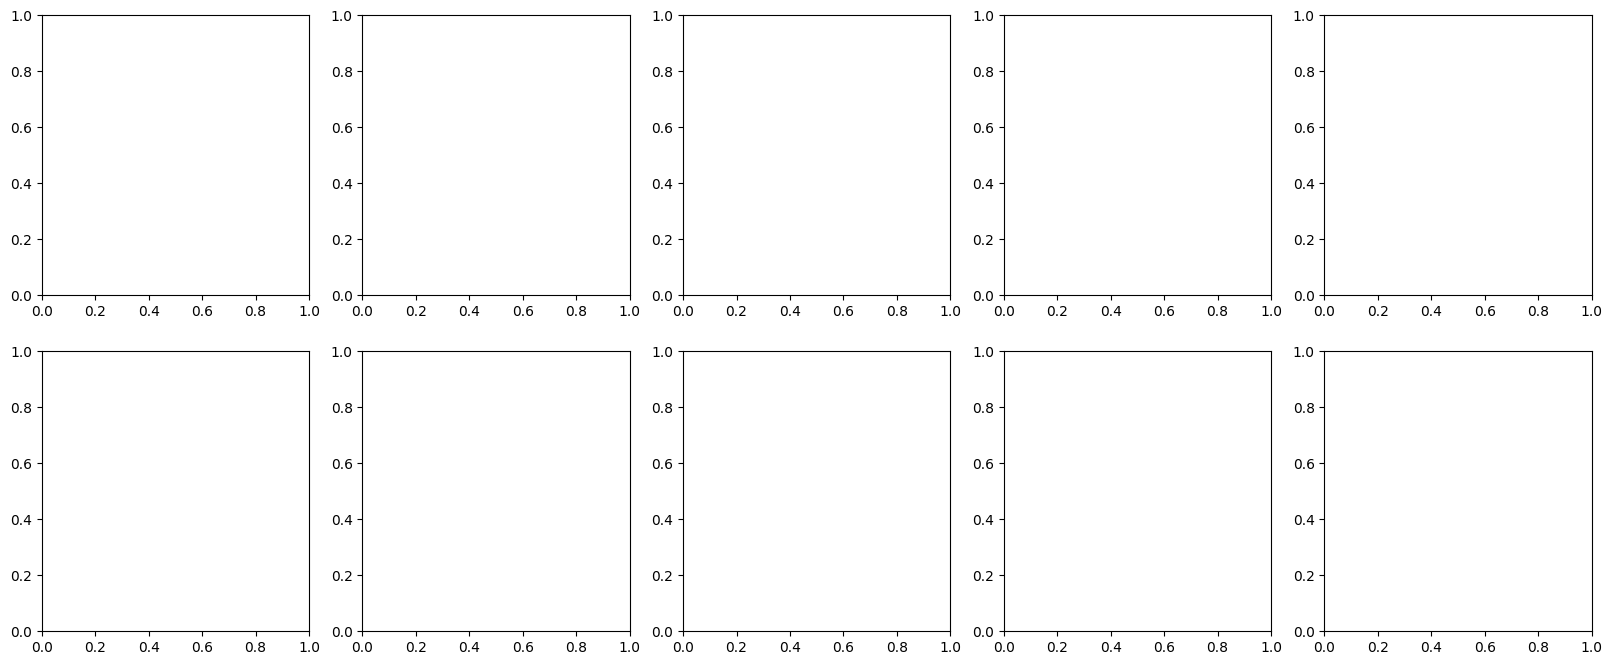

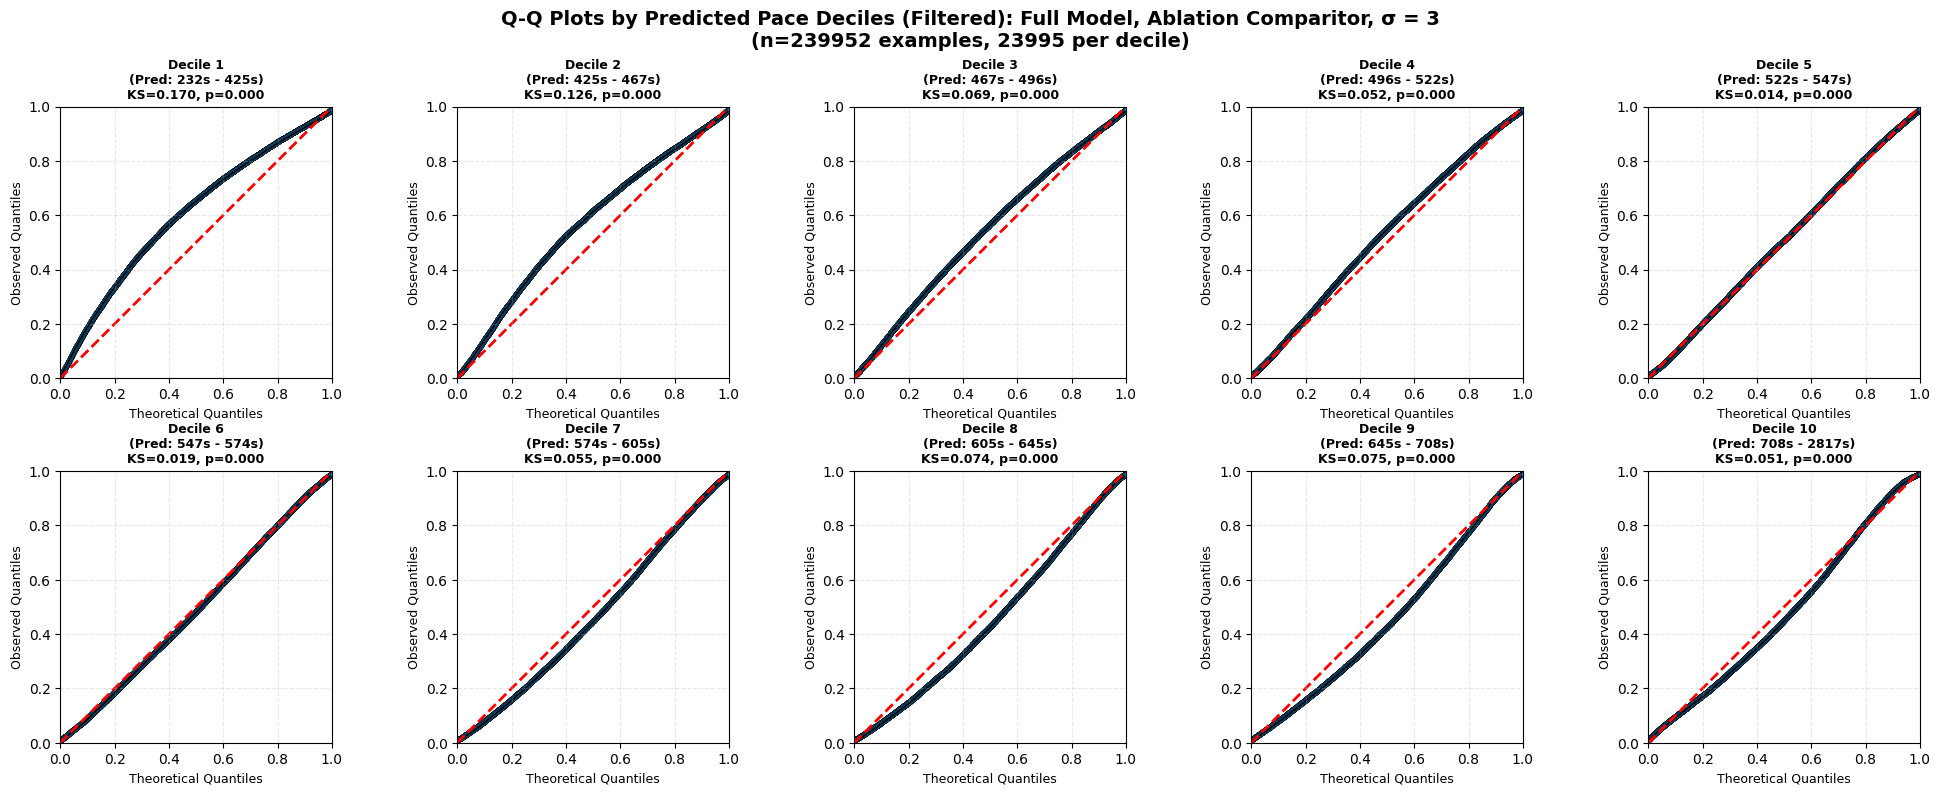

  Decile 1: 23824 ties in actual, 0 ties in predicted
  Decile 2: 23953 ties in actual, 2 ties in predicted
  Decile 3: 23964 ties in actual, 3 ties in predicted
  Decile 4: 23968 ties in actual, 4 ties in predicted
  Decile 5: 23968 ties in actual, 5 ties in predicted
  Decile 6: 23966 ties in actual, 3 ties in predicted
  Decile 7: 23962 ties in actual, 7 ties in predicted
  Decile 8: 23951 ties in actual, 6 ties in predicted
  Decile 9: 23923 ties in actual, 5 ties in predicted
  Decile 10: 23358 ties in actual, 9 ties in predicted


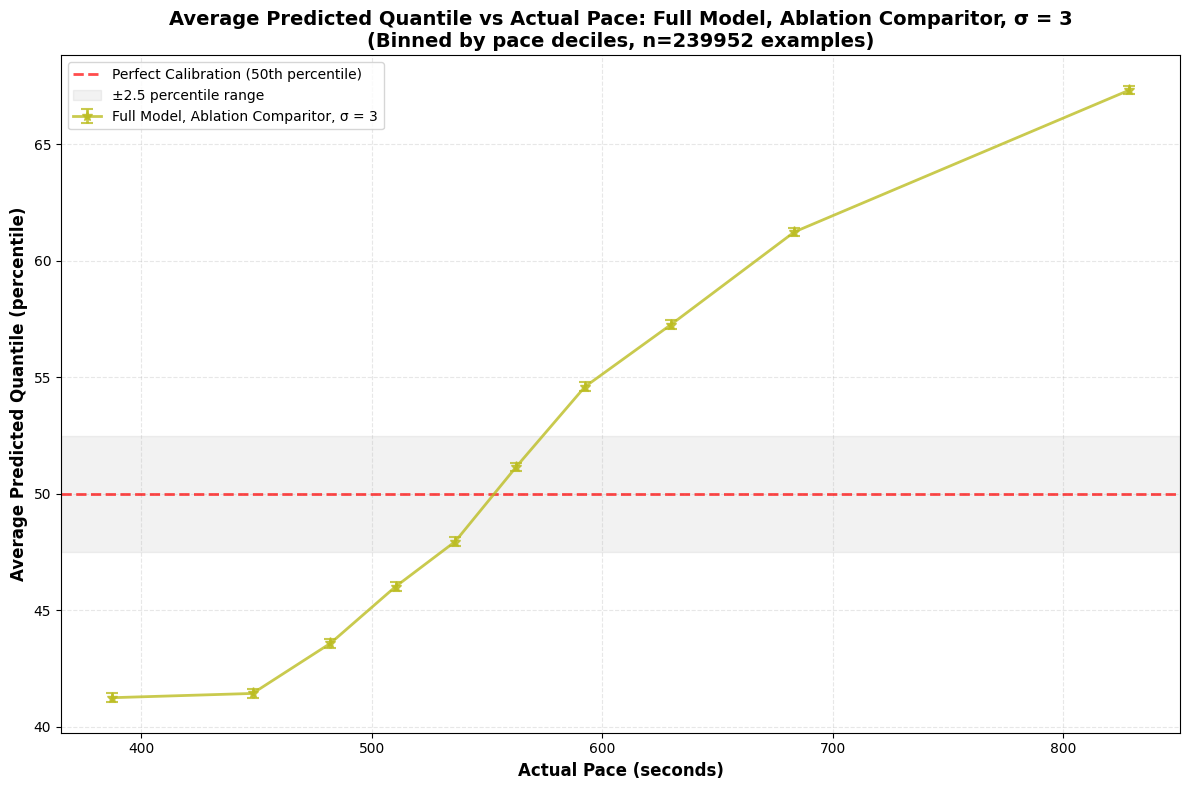

Summary Statistics:
  Overall mean percentile: 51.18
  Overall std percentile: 29.33
  Deviation from 50: 1.18

By Pace Decile:
Decile   Pace Range                N      Mean %ile    Std %ile     SEM       
--------------------------------------------------------------------------------
1        246s - 426s      23995  41.25        28.06        0.18      
2        426s - 467s      23995  41.43        28.29        0.18      
3        467s - 497s      23995  43.58        27.80        0.18      
4        497s - 523s      23995  46.01        28.20        0.18      
5        523s - 549s      23995  47.95        28.35        0.18      
6        549s - 577s      23995  51.14        28.66        0.19      
7        577s - 609s      23995  54.59        28.71        0.19      
8        609s - 652s      23995  57.26        28.33        0.18      
9        652s - 723s      23995  61.23        27.64        0.18      
10       723s - 3288s      23997  67.32        27.02        0.17      

CALIBRATIO

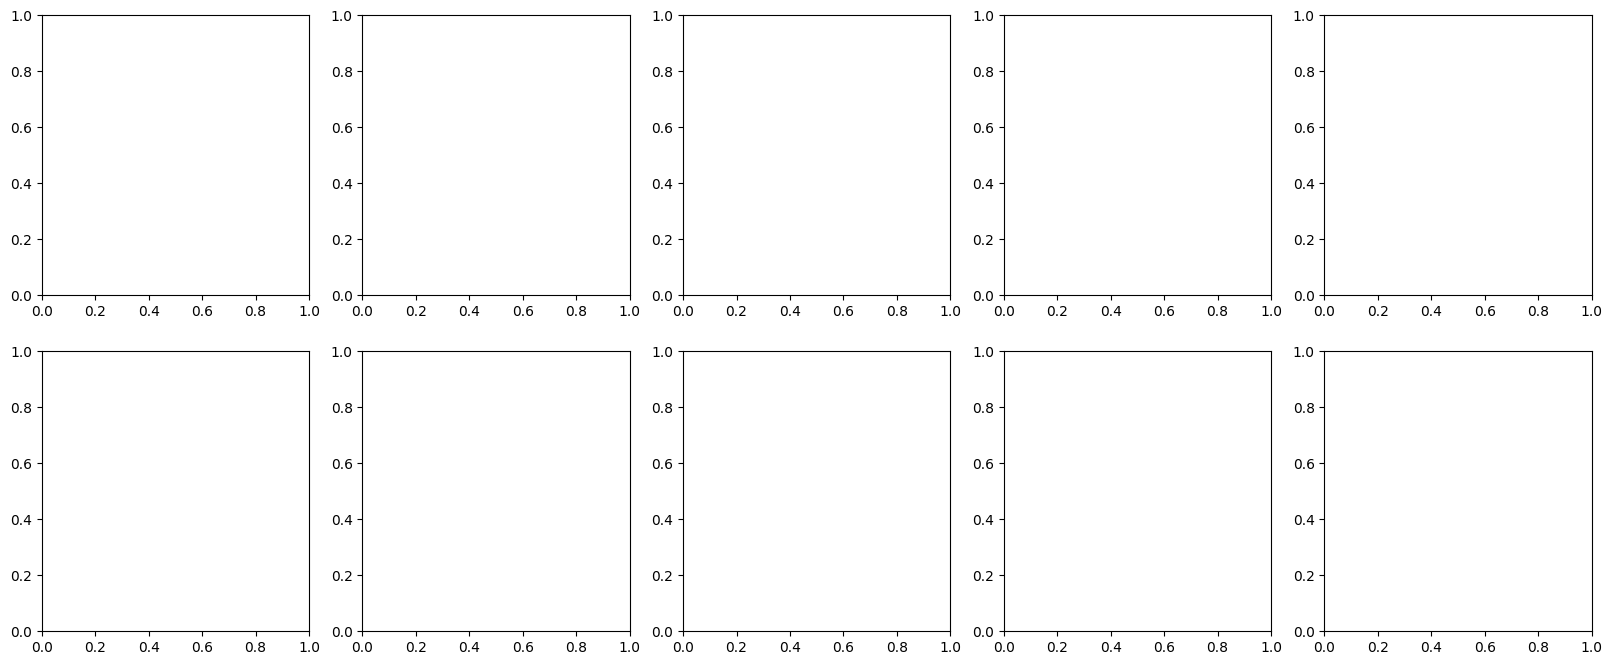

In [84]:
# ========================================================================
# DECILE ANALYSIS FOR ALL MODELS
# ========================================================================
# Loop through all models that have percentile data
models_to_analyze = list(percentiles_by_model.keys())

if len(models_to_analyze) == 0:
    print("❌ ERROR: No models available in percentiles_by_model")
else:
    print("="*80)
    print(f"CALIBRATION ANALYSIS BY PACE DECILES")
    print(f"Analyzing {len(models_to_analyze)} models")
    print("="*80)
    print()
    
    # Loop through each model
        # Initialize storage for combined plot
    if not hasattr(globals(), "quantile_plot_data"):
        quantile_plot_data = {}
        
        # Initialize storage for Spearman correlation plot
        if not hasattr(globals(), "spearman_plot_data"):
            spearman_plot_data = {}
        
    for model_idx, MODEL_TO_ANALYZE in enumerate(models_to_analyze):
        display_label = model_labels.get(MODEL_TO_ANALYZE, MODEL_TO_ANALYZE)
        print("\n" + "="*80)
        print(f"MODEL {model_idx + 1}/{len(models_to_analyze)}: {display_label} ({MODEL_TO_ANALYZE})")
        print("="*80)
        print()

        if MODEL_TO_ANALYZE not in percentiles_by_model:
            print(f"⚠️  Skipping {MODEL_TO_ANALYZE} - not in percentiles_by_model")
            continue
        
        # Get the data source info for this model to know which indices to use
        if MODEL_TO_ANALYZE in model_data_source:
            source_info = model_data_source[MODEL_TO_ANALYZE]
            # Get the subset of xgb_successful_indices that correspond to this model's data
            model_xgb_indices = xgb_successful_indices[source_info['xgb_indices_start']:source_info['xgb_indices_end']]
            print(f"Using data from file: {source_info['file']}")
            print(f"XGBoost indices range: {source_info['xgb_indices_start']} to {source_info['xgb_indices_end']} (out of {len(xgb_successful_indices)} total)")
        else:
            # Fallback: use all indices (for backward compatibility with single-file data)
            model_xgb_indices = xgb_successful_indices
            print(f"⚠️  Warning: No data source info found for {MODEL_TO_ANALYZE}, using all indices")


    
        # Collect actual paces and percentiles for this model
        print("Collecting actual paces and percentiles...")
        actual_paces = []
        percentiles = []
        
        # Iterate over the model-specific indices
        for idx, i in enumerate(model_xgb_indices):
            ex = mae_examples[i]
            actual_pace = ex.actual_pace_seconds
            percentile = percentiles_by_model[MODEL_TO_ANALYZE][idx]  # idx is position in model_xgb_indices, which matches percentiles
            
            actual_paces.append(actual_pace)
            percentiles.append(percentile)
        
        actual_paces = np.array(actual_paces)
        percentiles = np.array(percentiles)
        
        print(f"✓ Collected {len(actual_paces)} examples")
        print(f"  Actual pace range: {actual_paces.min():.1f}s to {actual_paces.max():.1f}s")
        print()
        
        # Sort by actual pace
        sort_indices = np.argsort(actual_paces)
        sorted_actual_paces = actual_paces[sort_indices]
        sorted_percentiles = percentiles[sort_indices]
        
        # Divide into 10 deciles
        n_examples = len(sorted_actual_paces)
        decile_size = n_examples // 10
        decile_boundaries = []
        
        for i in range(10):
            start_idx = i * decile_size
            end_idx = (i + 1) * decile_size if i < 9 else n_examples
            decile_boundaries.append((start_idx, end_idx))
        
        print("Decile boundaries:")
        for i, (start, end) in enumerate(decile_boundaries):
            pace_min = sorted_actual_paces[start]
            pace_max = sorted_actual_paces[end - 1]
            print(f"  Decile {i+1}: {start}-{end-1} examples, pace range: {pace_min:.1f}s - {pace_max:.1f}s")
        print()
        
        # ========================================================================
        # PLOT: Average Predicted Quantile vs Actual Pace (with error bars)
        # ========================================================================
        print("\n" + "="*80)
        print("AVERAGE PREDICTED QUANTILE VS ACTUAL PACE")
        print("="*80)
        print()
        
        # Create bins by actual pace (use deciles for consistency)
        
        # Filter: Drop runners whose predicted quantile (percentile) is > 99 or < 1
        # Also filter out runners whose actual OR predicted pace is in the final bin
        # Get pace_bins to check final bin boundaries
        pace_bins_for_filter = None
        if len(example_predictions) > 0:
            for ex_pred in example_predictions:
                if 'predictions_by_model' in ex_pred and MODEL_TO_ANALYZE in ex_pred['predictions_by_model']:
                    model_pred = ex_pred['predictions_by_model'][MODEL_TO_ANALYZE]
                    if 'pace_bins' in model_pred:
                        pace_bins_for_filter = model_pred['pace_bins']
                        break
        
        # Fallback: check calibration_data
        if pace_bins_for_filter is None and MODEL_TO_ANALYZE in calibration_data:
            if 'pace_bins' in calibration_data[MODEL_TO_ANALYZE]:
                pace_bins_for_filter = calibration_data[MODEL_TO_ANALYZE]['pace_bins']
        
        filtered_indices = []
        final_bin_start = None
        final_bin_end = None
        
        if pace_bins_for_filter:
            final_bin = pace_bins_for_filter[-1]  # Last bin
            final_bin_start = final_bin['start']
            final_bin_end = final_bin['end']
        
        # percentiles is already a numpy array, so we can use it directly
        for idx in range(len(percentiles)):
            percentile = percentiles[idx]
            actual_pace = actual_paces[idx]
            
            # Filter 1: Drop if percentile > 99 or < 1
            if percentile < 1 or percentile > 99:
                continue
            
            # Filter 2: Drop if actual pace is in final bin
            if pace_bins_for_filter:
                if final_bin_start <= actual_pace < final_bin_end:
                    continue
                
                # Filter 3: Drop if predicted pace is in final bin
                # Estimate predicted pace from percentile
                # If percentile is very high (>90), predicted pace is likely slower (higher) than actual
                # If percentile is very low (<10), predicted pace is likely faster (lower) than actual
                # We'll estimate predicted median pace from percentile
                bin_medians = np.array([b['median'] for b in pace_bins_for_filter])
                
                # Find which bin contains actual_pace
                actual_bin_idx = None
                for bin_idx, b in enumerate(pace_bins_for_filter):
                    if b['start'] <= actual_pace < b['end']:
                        actual_bin_idx = bin_idx
                        break
                
                if actual_bin_idx is not None:
                    # Estimate predicted bin from percentile
                    # If percentile = 50, predicted ≈ actual (same bin)
                    # If percentile > 50, model predicted faster (lower bin index)
                    # If percentile < 50, model predicted slower (higher bin index)
                    percentile_diff = percentile - 50.0
                    bin_shift = -percentile_diff / 4.0  # Rough approximation
                    predicted_bin_idx = int(np.clip(actual_bin_idx + bin_shift, 0, len(pace_bins_for_filter) - 1))
                    
                    # Check if predicted bin is the final bin
                    if predicted_bin_idx == len(pace_bins_for_filter) - 1:
                        continue
                else:
                    # Fallback: if actual pace is very high and percentile is very high, likely in final bin
                    if actual_pace >= final_bin_start and percentile > 90:
                        continue
            
            # Passed all filters
            filtered_indices.append(idx)
        
        num_filtered_out = len(percentiles) - len(filtered_indices)
        print(f"Filtered out {num_filtered_out} examples:")
        print(f"  - Predicted quantile > 99 or < 1")
        print(f"  - Actual pace in final bin")
        print(f"  - Predicted pace in final bin")
        print(f"Using {len(filtered_indices)} examples for quantile plot")
        
        # Apply filter to the data
        # Convert filtered_indices to numpy array for proper indexing
        filtered_indices = np.array(filtered_indices)
        filtered_actual_paces = actual_paces[filtered_indices]
        filtered_percentiles = percentiles[filtered_indices]
        
        print(f"✓ Filtered data: {len(filtered_actual_paces)} actual paces, {len(filtered_percentiles)} percentiles")
        
        # ========================================================================
        # COMPUTE PREDICTED PACES FOR FILTERED DATA (needed for predicted pace deciles)
        # ========================================================================
        # Compute predicted paces from filtered percentiles and actual paces
        predicted_paces_for_qq = []
        
        # Get pace_bins for this model to estimate predicted paces
        pace_bins_qq = None
        if len(example_predictions) > 0:
            for ex_pred in example_predictions:
                if 'predictions_by_model' in ex_pred and MODEL_TO_ANALYZE in ex_pred['predictions_by_model']:
                    model_pred = ex_pred['predictions_by_model'][MODEL_TO_ANALYZE]
                    if 'pace_bins' in model_pred:
                        pace_bins_qq = model_pred['pace_bins']
                        break
        
        # Fallback: check calibration_data
        if pace_bins_qq is None and MODEL_TO_ANALYZE in calibration_data:
            if 'pace_bins' in calibration_data[MODEL_TO_ANALYZE]:
                pace_bins_qq = calibration_data[MODEL_TO_ANALYZE]['pace_bins']
        
        # Compute predicted paces from filtered percentiles and actual paces
        # Precompute arrays once (not inside the loop)
        if pace_bins_qq:
            bin_medians = np.array([b['median'] for b in pace_bins_qq])
            bin_starts = np.array([b['start'] for b in pace_bins_qq])
            bin_ends = np.array([b['end'] for b in pace_bins_qq])
            pace_range = bin_ends[-1] - bin_starts[0]  # Precompute once
        else:
            bin_medians = None
            bin_starts = None
            bin_ends = None
            pace_range = None
        
        # Vectorized computation
        filtered_actual_paces_arr = np.array(filtered_actual_paces)
        filtered_percentiles_arr = np.array(filtered_percentiles)
        percentile_diffs = filtered_percentiles_arr - 50.0
        
        if pace_bins_qq:
            # Vectorized: find which bin each actual_pace falls into
            actual_bin_indices = np.searchsorted(bin_ends, filtered_actual_paces_arr)
            # Clip to valid range
            actual_bin_indices = np.clip(actual_bin_indices, 0, len(bin_medians) - 1)
            
            # Compute predicted bin indices (vectorized)
            bin_shifts = -percentile_diffs / 4.0
            predicted_bin_indices = np.clip(actual_bin_indices + bin_shifts, 0, len(bin_medians) - 1).astype(int)
            predicted_paces_for_qq = bin_medians[predicted_bin_indices]
            
            # Handle cases where actual_pace is outside bin range (use fallback)
            out_of_range_mask = (filtered_actual_paces_arr < bin_starts[0]) | (filtered_actual_paces_arr >= bin_ends[-1])
            if np.any(out_of_range_mask):
                # Fallback for out-of-range values
                small_diff_mask = out_of_range_mask & (np.abs(percentile_diffs) < 5)
                predicted_paces_for_qq[small_diff_mask] = filtered_actual_paces_arr[small_diff_mask]
                
                large_diff_mask = out_of_range_mask & ~small_diff_mask
                if np.any(large_diff_mask):
                    adjustments = (percentile_diffs[large_diff_mask] / 100.0) * pace_range * 0.15
                    predicted_paces_for_qq[large_diff_mask] = filtered_actual_paces_arr[large_diff_mask] - adjustments
        else:
            # Simple approximation without pace_bins (vectorized)
            percentile_deviations = percentile_diffs / 50.0
            adjustment_factor = 0.15
            predicted_paces_for_qq = filtered_actual_paces_arr * (1 - percentile_deviations * adjustment_factor)
        
        predicted_paces_for_qq = np.array(predicted_paces_for_qq)
        
        # Ensure filtered_percentiles is a numpy array
        if not isinstance(filtered_percentiles, np.ndarray):
            filtered_percentiles = np.array(filtered_percentiles)
        if not isinstance(filtered_actual_paces, np.ndarray):
            filtered_actual_paces = np.array(filtered_actual_paces)
        
        # Sort by predicted pace (not actual pace) for Q-Q plot deciles
        sort_indices_by_predicted = np.argsort(predicted_paces_for_qq)
        sorted_predicted_paces_qq = predicted_paces_for_qq[sort_indices_by_predicted]
        sorted_percentiles_by_predicted = filtered_percentiles[sort_indices_by_predicted]
        sorted_actual_paces_by_predicted = filtered_actual_paces[sort_indices_by_predicted]
        
        # Debug: verify data
        print(f"  ✓ Sorted data: {len(sorted_percentiles_by_predicted)} percentiles, {len(sorted_predicted_paces_qq)} predicted paces")
        print(f"    Percentile range: {sorted_percentiles_by_predicted.min():.1f} to {sorted_percentiles_by_predicted.max():.1f}")
        print(f"    Predicted pace range: {sorted_predicted_paces_qq.min():.1f}s to {sorted_predicted_paces_qq.max():.1f}s")
        
        # ========================================================================
        # CREATE Q-Q PLOTS FOR EACH DECILE (stratified by predicted pace)
        # ========================================================================
        # Create decile boundaries based on predicted pace
        n_filtered = len(sorted_predicted_paces_qq)
        print(f"Creating Q-Q plots with {n_filtered} filtered examples (stratified by predicted pace)")
        
        if n_filtered == 0:
            print("⚠️  WARNING: No filtered data available! Skipping Q-Q plots.")
        else:
            decile_size_filtered = n_filtered // 10
            decile_boundaries_by_predicted = []
            
            for i in range(10):
                start_idx = i * decile_size_filtered
                end_idx = (i + 1) * decile_size_filtered if i < 9 else n_filtered
                decile_boundaries_by_predicted.append((start_idx, end_idx))
            
            # Create Q-Q plots for each decile using filtered data
            fig, axes = plt.subplots(2, 5, figsize=(20, 8))
            axes = axes.flatten()
            
            ks_statistics = []
            ks_pvalues = []
            
            for decile_idx in range(10):
                start, end = decile_boundaries_by_predicted[decile_idx]
                decile_percentiles = sorted_percentiles_by_predicted[start:end]
                
                if len(decile_percentiles) == 0:
                    print(f"⚠️  WARNING: Decile {decile_idx+1} has no data (start={start}, end={end})")
                    # Hide this subplot
                    axes[decile_idx].axis('off')
                    ks_statistics.append(np.nan)
                    ks_pvalues.append(np.nan)
                    continue
                
                # Convert to 0-1 range for Q-Q plot
                decile_percentiles_fraction = decile_percentiles / 100.0
                
                # Sort for Q-Q plot
                sorted_decile_percentiles = np.sort(decile_percentiles_fraction)
                n_decile = len(sorted_decile_percentiles)
                
                if n_decile == 0:
                    print(f"⚠️  WARNING: Decile {decile_idx+1} has 0 data points after conversion")
                    axes[decile_idx].axis('off')
                    ks_statistics.append(np.nan)
                    ks_pvalues.append(np.nan)
                    continue
                
                theoretical_quantiles = np.linspace(0, 1, n_decile)
                
                # Debug: verify data before plotting
                if decile_idx == 0:  # Print debug for first decile only
                    print(f"  Debug Decile 1: n={n_decile}, min={sorted_decile_percentiles.min():.3f}, max={sorted_decile_percentiles.max():.3f}")
                    print(f"    theoretical_quantiles range: {theoretical_quantiles.min():.3f} to {theoretical_quantiles.max():.3f}")
                
                # Compute KS statistic
                ks_stat, ks_pval = kstest(decile_percentiles_fraction, 'uniform')
                ks_statistics.append(ks_stat)
                ks_pvalues.append(ks_pval)
                
                # Plot Q-Q plot
                ax = axes[decile_idx]
                # Ensure we have valid data to plot
                if n_decile > 0 and len(theoretical_quantiles) == n_decile and len(sorted_decile_percentiles) == n_decile:
                    ax.scatter(theoretical_quantiles, sorted_decile_percentiles, alpha=0.5, s=10, edgecolors='black', linewidths=0.3)
                    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration', zorder=1)
                else:
                    print(f"⚠️  WARNING: Decile {decile_idx+1} data mismatch: n_decile={n_decile}, len(theoretical)={len(theoretical_quantiles)}, len(sorted)={len(sorted_decile_percentiles)}")
                    axes[decile_idx].axis('off')
                    continue
                ax.set_xlabel('Theoretical Quantiles', fontsize=9)
                ax.set_ylabel('Observed Quantiles', fontsize=9)
                ax.set_title(f'Decile {decile_idx+1}\n(Pred: {sorted_predicted_paces_qq[start]:.0f}s - {sorted_predicted_paces_qq[end-1]:.0f}s)\nKS={ks_stat:.3f}, p={ks_pval:.3f}', 
                        fontsize=9, fontweight='bold')
                ax.grid(True, alpha=0.3, linestyle='--')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_aspect('equal')
            
            plt.suptitle(f'Q-Q Plots by Predicted Pace Deciles (Filtered): {display_label}\n(n={n_filtered} examples, {decile_size_filtered} per decile)', 
                     fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        
        # ========================================================================
        # RE-SORT BY ACTUAL PACE FOR SPEARMAN CORRELATION (uses actual pace deciles)
        # ========================================================================
        # Spearman correlation should still use actual pace deciles
        sort_indices_filtered = np.argsort(filtered_actual_paces)
        sorted_actual_paces_filtered = filtered_actual_paces[sort_indices_filtered]
        sorted_percentiles_filtered = filtered_percentiles[sort_indices_filtered]
        
        # Create decile boundaries for actual pace (for Spearman correlation)
        n_filtered_actual = len(sorted_actual_paces_filtered)
        decile_size_filtered_actual = n_filtered_actual // 10
        decile_boundaries_filtered = []
        
        for i in range(10):
            start_idx = i * decile_size_filtered_actual
            end_idx = (i + 1) * decile_size_filtered_actual if i < 9 else n_filtered_actual
            decile_boundaries_filtered.append((start_idx, end_idx))
        
        # ========================================================================
        # COMPUTE SPEARMAN CORRELATION FOR EACH DECILE (using filtered data)
        # ========================================================================
        # Compute predicted paces for Spearman correlation using filtered data
        # We need predicted paces to compute rank-order correlation
        predicted_paces_for_spearman_filtered = []
        
        # Get pace_bins for this model to estimate predicted paces
        pace_bins_spearman = None
        if len(example_predictions) > 0:
            for ex_pred in example_predictions:
                if 'predictions_by_model' in ex_pred and MODEL_TO_ANALYZE in ex_pred['predictions_by_model']:
                    model_pred = ex_pred['predictions_by_model'][MODEL_TO_ANALYZE]
                    if 'pace_bins' in model_pred:
                        pace_bins_spearman = model_pred['pace_bins']
                        break
        
        # Fallback: check calibration_data
        if pace_bins_spearman is None and MODEL_TO_ANALYZE in calibration_data:
            if 'pace_bins' in calibration_data[MODEL_TO_ANALYZE]:
                pace_bins_spearman = calibration_data[MODEL_TO_ANALYZE]['pace_bins']
        
        # Compute predicted paces from filtered percentiles and actual paces
        # Precompute arrays once (not inside the loop)
        if pace_bins_spearman:
            bin_medians = np.array([b['median'] for b in pace_bins_spearman])
            bin_starts = np.array([b['start'] for b in pace_bins_spearman])
            bin_ends = np.array([b['end'] for b in pace_bins_spearman])
            pace_range = bin_ends[-1] - bin_starts[0]  # Precompute once
        else:
            bin_medians = None
            bin_starts = None
            bin_ends = None
            pace_range = None
        
        # Vectorized computation
        filtered_actual_paces_arr = np.array(filtered_actual_paces)
        filtered_percentiles_arr = np.array(filtered_percentiles)
        percentile_diffs = filtered_percentiles_arr - 50.0
        
        if pace_bins_spearman:
            # Vectorized: find which bin each actual_pace falls into
            actual_bin_indices = np.searchsorted(bin_ends, filtered_actual_paces_arr)
            # Clip to valid range
            actual_bin_indices = np.clip(actual_bin_indices, 0, len(bin_medians) - 1)
            
            # Compute predicted bin indices (vectorized)
            bin_shifts = -percentile_diffs / 4.0
            predicted_bin_indices = np.clip(actual_bin_indices + bin_shifts, 0, len(bin_medians) - 1).astype(int)
            predicted_paces_for_spearman_filtered = bin_medians[predicted_bin_indices]
            
            # Handle cases where actual_pace is outside bin range (use fallback)
            out_of_range_mask = (filtered_actual_paces_arr < bin_starts[0]) | (filtered_actual_paces_arr >= bin_ends[-1])
            if np.any(out_of_range_mask):
                # Fallback for out-of-range values
                small_diff_mask = out_of_range_mask & (np.abs(percentile_diffs) < 5)
                predicted_paces_for_spearman_filtered[small_diff_mask] = filtered_actual_paces_arr[small_diff_mask]
                
                large_diff_mask = out_of_range_mask & ~small_diff_mask
                if np.any(large_diff_mask):
                    adjustments = (percentile_diffs[large_diff_mask] / 100.0) * pace_range * 0.15
                    predicted_paces_for_spearman_filtered[large_diff_mask] = filtered_actual_paces_arr[large_diff_mask] - adjustments
        else:
            # Simple approximation without pace_bins (vectorized)
            percentile_deviations = percentile_diffs / 50.0
            adjustment_factor = 0.15
            predicted_paces_for_spearman_filtered = filtered_actual_paces_arr * (1 - percentile_deviations * adjustment_factor)
        
        predicted_paces_for_spearman_filtered = predicted_paces_for_spearman_filtered.tolist()
        
        # Sort predicted paces to match sorted_actual_paces_filtered order
        predicted_paces_sorted_filtered = np.array(predicted_paces_for_spearman_filtered)[sort_indices_filtered]
        
        # Compute Spearman correlation for each decile using filtered data
        # Note: scipy.stats.spearmanr handles ties using the average rank (midrank) method:
        # When values are tied, they receive the average of the ranks they would have occupied.
        # This is the standard approach for Spearman correlation with ties.
        from scipy.stats import spearmanr
        spearman_coefficients = []
        spearman_pvalues = []
        
        for decile_idx in range(10):
            start, end = decile_boundaries_filtered[decile_idx]
            decile_actual = sorted_actual_paces_filtered[start:end]
            decile_predicted = predicted_paces_sorted_filtered[start:end]
            
            if len(decile_actual) > 1:
                # Count ties for diagnostic purposes (optional)
                n_unique_actual = len(np.unique(decile_actual))
                n_unique_predicted = len(np.unique(decile_predicted))
                n_ties_actual = len(decile_actual) - n_unique_actual
                n_ties_predicted = len(decile_predicted) - n_unique_predicted
                
                # Compute Spearman correlation (automatically handles ties with average ranks)
                spearman_coef, spearman_pval = spearmanr(decile_actual, decile_predicted)
                spearman_coefficients.append(spearman_coef)
                spearman_pvalues.append(spearman_pval)
                
                # Optional: print tie information if there are many ties
                if n_ties_actual > len(decile_actual) * 0.1 or n_ties_predicted > len(decile_predicted) * 0.1:
                    print(f"  Decile {decile_idx+1}: {n_ties_actual} ties in actual, {n_ties_predicted} ties in predicted")
            else:
                spearman_coefficients.append(np.nan)
                spearman_pvalues.append(np.nan)
        
        # Store Spearman data for combined plot
        spearman_plot_data[MODEL_TO_ANALYZE] = {
            "spearman_coefficients": np.array(spearman_coefficients),
            "spearman_pvalues": np.array(spearman_pvalues),
            "display_label": display_label
        }
        
        pace_bins_for_plot = []
        mean_percentiles = []
        std_percentiles = []
        sem_percentiles = []  # Standard error of the mean
        bin_centers = []
        bin_counts = []
        
        for decile_idx in range(10):
            # Calculate decile boundaries for filtered data
            n_filtered = len(sorted_actual_paces_filtered)
            decile_size_filtered = n_filtered // 10
            start_idx_filtered = decile_idx * decile_size_filtered
            end_idx_filtered = (decile_idx + 1) * decile_size_filtered if decile_idx < 9 else n_filtered
            
            decile_percentiles = sorted_percentiles_filtered[start_idx_filtered:end_idx_filtered]
            decile_actual_paces = sorted_actual_paces_filtered[start_idx_filtered:end_idx_filtered]
            
            
            if len(decile_percentiles) > 0:
                # Calculate statistics for this decile
                mean_perc = np.mean(decile_percentiles)
                std_perc = np.std(decile_percentiles)
                sem_perc = std_perc / np.sqrt(len(decile_percentiles))  # Standard error
                bin_center = np.mean(decile_actual_paces)
                
                pace_bins_for_plot.append((decile_actual_paces.min(), decile_actual_paces.max()))
                mean_percentiles.append(mean_perc)
                std_percentiles.append(std_perc)
                sem_percentiles.append(sem_perc)
                bin_centers.append(bin_center)
                bin_counts.append(len(decile_percentiles))
        
        # Convert to numpy arrays for storage
        bin_centers = np.array(bin_centers)
        mean_percentiles = np.array(mean_percentiles)
        sem_percentiles = np.array(sem_percentiles)
        
        # Store data for combined plot
        quantile_plot_data[MODEL_TO_ANALYZE] = {
            "bin_centers": bin_centers,
            "mean_percentiles": mean_percentiles,
            "sem_percentiles": sem_percentiles,
            "display_label": display_label,
            "n_examples": len(filtered_indices)
        }
        
        # Plot individual chart for this model
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Get color and marker for this model
        color = model_colors.get(MODEL_TO_ANALYZE, 'gray')
        marker = model_markers.get(MODEL_TO_ANALYZE, 'o')
        
        # Plot with error bars
        ax.errorbar(bin_centers, mean_percentiles, yerr=sem_percentiles,
                   fmt=marker + '-', markersize=8, capsize=4, capthick=1.5,
                   linewidth=2, label=display_label, color=color, alpha=0.8)
        
        # Add horizontal line at 50 (perfect calibration)
        ax.axhline(y=50, color='r', linestyle='--', linewidth=2,
                  label='Perfect Calibration (50th percentile)', alpha=0.7)
        
        # Add shaded region for ±2.5 percentile around 50
        ax.axhspan(50 - 2.5, 50 + 2.5, alpha=0.1, color='gray',
                  label='±2.5 percentile range')
        
        ax.set_xlabel('Actual Pace (seconds)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average Predicted Quantile (percentile)', fontsize=12, fontweight='bold')
        ax.set_title(f'Average Predicted Quantile vs Actual Pace: {display_label}\n(Binned by pace deciles, n={len(filtered_indices)} examples)',
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=10, loc='best')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("Summary Statistics:")
        print(f"  Overall mean percentile: {np.mean(sorted_percentiles_filtered):.2f}")
        print(f"  Overall std percentile: {np.std(sorted_percentiles_filtered):.2f}")
        print(f"  Deviation from 50: {np.mean(sorted_percentiles_filtered) - 50:.2f}")
        print()
        print("By Pace Decile:")
        print(f"{'Decile':<8} {'Pace Range':<25} {'N':<6} {'Mean %ile':<12} {'Std %ile':<12} {'SEM':<10}")
        print("-"*80)
        for decile_idx in range(10):
            # Calculate decile boundaries for filtered data
            n_filtered = len(sorted_actual_paces_filtered)
            decile_size_filtered = n_filtered // 10
            start_idx_filtered = decile_idx * decile_size_filtered
            end_idx_filtered = (decile_idx + 1) * decile_size_filtered if decile_idx < 9 else n_filtered
            
            decile_percentiles = sorted_percentiles_filtered[start_idx_filtered:end_idx_filtered]
            decile_actual_paces = sorted_actual_paces_filtered[start_idx_filtered:end_idx_filtered]
            
            pace_min = sorted_actual_paces_filtered[start_idx_filtered]
            pace_max = sorted_actual_paces_filtered[end_idx_filtered - 1]
            n_decile = end_idx_filtered - start_idx_filtered
            mean_p = mean_percentiles[decile_idx]
            std_p = std_percentiles[decile_idx]
            sem_p = sem_percentiles[decile_idx]
            print(f"{decile_idx+1:<8} {pace_min:.0f}s - {pace_max:.0f}s{'':<5} {n_decile:<6} {mean_p:<12.2f} {std_p:<12.2f} {sem_p:<10.2f}")
        print("="*80)
        print()
        
        
        # Compute KS statistics for actual pace deciles (for calibration summary table)
        from scipy.stats import kstest
        ks_statistics_actual = []
        ks_pvalues_actual = []
        
        for decile_idx in range(10):
            # Calculate decile boundaries for filtered data
            n_filtered = len(sorted_actual_paces_filtered)
            decile_size_filtered = n_filtered // 10
            start_idx_filtered = decile_idx * decile_size_filtered
            end_idx_filtered = (decile_idx + 1) * decile_size_filtered if decile_idx < 9 else n_filtered
            
            decile_percentiles = sorted_percentiles_filtered[start_idx_filtered:end_idx_filtered]
            
            if len(decile_percentiles) > 0:
                # Convert to 0-1 range for KS test
                decile_percentiles_fraction = decile_percentiles / 100.0
                # KS test: null hypothesis is that percentiles follow Uniform(0,1)
                ks_stat, ks_pval = kstest(decile_percentiles_fraction, 'uniform')
                ks_statistics_actual.append(ks_stat)
                ks_pvalues_actual.append(ks_pval)
            else:
                ks_statistics_actual.append(np.nan)
                ks_pvalues_actual.append(np.nan)
        
        # Print summary table
        print("="*80)
        print("CALIBRATION SUMMARY BY DECILE")
        print("="*80)
        print(f"{'Decile':<8} {'Pace Range':<20} {'N':<6} {'KS Stat':<10} {'P-value':<10} {'Calibrated?':<12}")
        print("-"*80)
        
        for decile_idx in range(10):
            # Calculate decile boundaries for filtered data
            n_filtered = len(sorted_actual_paces_filtered)
            decile_size_filtered = n_filtered // 10
            start_idx_filtered = decile_idx * decile_size_filtered
            end_idx_filtered = (decile_idx + 1) * decile_size_filtered if decile_idx < 9 else n_filtered
            
            decile_percentiles = sorted_percentiles_filtered[start_idx_filtered:end_idx_filtered]
            decile_actual_paces = sorted_actual_paces_filtered[start_idx_filtered:end_idx_filtered]
            
            pace_min = sorted_actual_paces_filtered[start_idx_filtered]
            pace_max = sorted_actual_paces_filtered[end_idx_filtered - 1]
            n_decile = end_idx_filtered - start_idx_filtered
            ks_stat = ks_statistics_actual[decile_idx]
            ks_pval = ks_pvalues_actual[decile_idx]
            calibrated = "Yes" if not np.isnan(ks_pval) and ks_pval > 0.05 else "No"
            
            print(f"{decile_idx+1:<8} {pace_min:.0f}s - {pace_max:.0f}s{'':<5} {n_decile:<6} {ks_stat:<10.4f} {ks_pval:<10.4f} {calibrated:<12}")
        
        print("="*80)
        print()
        print("Interpretation:")
        print("  - KS Statistic: Lower is better (0 = perfect calibration)")
        print("  - P-value > 0.05: Cannot reject uniformity (well-calibrated)")
        print("  - P-value < 0.05: Significantly non-uniform (miscalibrated)")
        print()
        
        # ========================================================================
        # SEGMENT BY PREDICTED PACE DECILES (instead of actual pace)
        # ========================================================================
        print("="*80)
        print("CALIBRATION ANALYSIS BY PREDICTED PACE DECILES")
        print("="*80)
        print(f"Analyzing model: {display_label}")
        print()
        
        # Get predicted median paces for each example
        print("Collecting predicted paces and percentiles...")
        predicted_paces = []
        percentiles_by_predicted = []
        actual_paces_by_predicted = []
        
        # Get pace_bins to compute predicted median from percentiles
        # pace_bins are MODEL-SPECIFIC - each model may have different pace bins
        # They are stored in example_predictions per model, not in calibration_data
        pace_bins = None
        
        # Try to get pace_bins from example_predictions (model-specific)
        if len(example_predictions) > 0:
            # Check all example_predictions to find one with this model's pace_bins
            for ex_pred in example_predictions:
                if 'predictions_by_model' in ex_pred and MODEL_TO_ANALYZE in ex_pred['predictions_by_model']:
                    model_pred = ex_pred['predictions_by_model'][MODEL_TO_ANALYZE]
                    if 'pace_bins' in model_pred:
                        pace_bins = model_pred['pace_bins']
                        print(f"✓ Found pace_bins for {MODEL_TO_ANALYZE} in example_predictions")
                        break
        
        # Fallback: check calibration_data (though it typically doesn't have pace_bins)
        if pace_bins is None and MODEL_TO_ANALYZE in calibration_data:
            if 'pace_bins' in calibration_data[MODEL_TO_ANALYZE]:
                pace_bins = calibration_data[MODEL_TO_ANALYZE]['pace_bins']
                print(f"✓ Found pace_bins for {MODEL_TO_ANALYZE} in calibration_data")
        
        if pace_bins:
            # Compute predicted median from percentile and actual pace
            # The percentile tells us where actual_pace falls in the predicted distribution
            # To get predicted median (50th percentile), we need to find the pace at CDF=0.5
            # We'll use the pace_bins to estimate this
            
            # Get pace bin medians for interpolation
            bin_medians = np.array([b['median'] for b in pace_bins])
            pace_min = min([b['start'] for b in pace_bins])
            pace_max = max([b['end'] for b in pace_bins])
            
            # Use the same model-specific indices for predicted pace analysis
            for idx, i in enumerate(model_xgb_indices):
                ex = mae_examples[i]
                actual_pace = ex.actual_pace_seconds
                percentile = percentiles_by_model[MODEL_TO_ANALYZE][idx]  # idx matches position in percentiles list
                
                # Estimate predicted median from percentile
                # If percentile = 50, predicted_median ≈ actual_pace
                # If percentile > 50, model predicted faster, so predicted_median < actual_pace
                # If percentile < 50, model predicted slower, so predicted_median > actual_pace
                
                # Use pace_bins to find a better estimate
                # Find which bin contains actual_pace
                actual_bin_idx = None
                for bin_idx, b in enumerate(pace_bins):
                    if b['start'] <= actual_pace < b['end']:
                        actual_bin_idx = bin_idx
                        break
                
                if actual_bin_idx is not None:
                    # Estimate: if percentile is 50, predicted median is at the same bin as actual
                    # Otherwise, shift by the percentile difference
                    percentile_diff = percentile - 50.0  # Positive means model predicted faster
                    # Estimate shift in bins (rough approximation: 1 bin per ~4 percentile points)
                    bin_shift = -percentile_diff / 4.0  # Negative because if percentile high, predicted is lower
                    predicted_bin_idx = int(np.clip(actual_bin_idx + bin_shift, 0, len(pace_bins) - 1))
                    predicted_median = bin_medians[predicted_bin_idx]
                else:
                    # Fallback: use simple linear approximation
                    if abs(percentile - 50) < 5:
                        predicted_median = actual_pace
                    else:
                        pace_range = pace_max - pace_min
                        adjustment = (percentile - 50) / 100.0 * pace_range * 0.15
                        predicted_median = actual_pace - adjustment
                    
                predicted_paces.append(predicted_median)
                percentiles_by_predicted.append(percentile)
                actual_paces_by_predicted.append(actual_pace)
        else:
            # Fallback: Estimate predicted median from percentile without pace_bins
            # This is an approximation: if percentile = 50, predicted ≈ actual
            # If percentile > 50, model predicted faster (lower pace)
            # If percentile < 50, model predicted slower (higher pace)
            print("⚠️  pace_bins not available, using approximation method")
            print("   Estimating predicted median from percentile and actual pace")
            
            # Use the same model-specific indices for predicted pace analysis
            for idx, i in enumerate(model_xgb_indices):
                ex = mae_examples[i]
                actual_pace = ex.actual_pace_seconds
                percentile = percentiles_by_model[MODEL_TO_ANALYZE][idx]
                
                # Simple heuristic: if percentile is 50, predicted = actual
                # Otherwise, adjust based on percentile deviation
                # The adjustment factor is empirical - we use a percentage of actual pace
                # based on how far the percentile is from 50
                percentile_deviation = (percentile - 50) / 50.0  # -1 to +1
                
                # Estimate: if model predicted at 75th percentile, it's overconfident
                # and likely predicted a faster pace. Adjust accordingly.
                # Use a scaling factor (e.g., 0.1 means 10% adjustment for 50 percentile points)
                adjustment_factor = 0.15  # 15% max adjustment
                predicted_median = actual_pace * (1 - percentile_deviation * adjustment_factor)
                
                predicted_paces.append(predicted_median)
                percentiles_by_predicted.append(percentile)
                actual_paces_by_predicted.append(actual_pace)
            
            print(f"✓ Estimated predicted paces for {len(predicted_paces)} examples")
            print("   (Note: This is an approximation - actual predicted medians may differ)")
        
        if predicted_paces and len(predicted_paces) > 0:
            predicted_paces = np.array(predicted_paces)
            percentiles_by_predicted = np.array(percentiles_by_predicted)
            actual_paces_by_predicted = np.array(actual_paces_by_predicted)
            
            print(f"✓ Collected {len(predicted_paces)} examples with predicted paces")
            print(f"  Predicted pace range: {predicted_paces.min():.1f}s to {predicted_paces.max():.1f}s")
            print()
            
            # Sort by predicted pace
            sort_indices = np.argsort(predicted_paces)
            sorted_predicted_paces = predicted_paces[sort_indices]
            sorted_percentiles_by_pred = percentiles_by_predicted[sort_indices]
            sorted_actual_by_pred = actual_paces_by_predicted[sort_indices]
            
            # Divide into 10 deciles based on predicted pace
            n_examples_pred = len(sorted_predicted_paces)
            decile_size_pred = n_examples_pred // 10
            decile_boundaries_pred = []
            
            for i in range(10):
                start_idx = i * decile_size_pred
                end_idx = (i + 1) * decile_size_pred if i < 9 else n_examples_pred
                decile_boundaries_pred.append((start_idx, end_idx))
            
            print("Predicted pace decile boundaries:")
            for i, (start, end) in enumerate(decile_boundaries_pred):
                pred_min = sorted_predicted_paces[start]
                pred_max = sorted_predicted_paces[end - 1]
                print(f"  Decile {i+1}: {start}-{end-1} examples, predicted pace range: {pred_min:.1f}s - {pred_max:.1f}s")
            print()
            
            # Create Q-Q plots for each predicted pace decile
            fig, axes = plt.subplots(2, 5, figsize=(20, 8))
            axes = axes.flatten()
            
            ks_statistics_pred = []
            ks_pvalues_pred = []


## Step 9: Combined Average Predicted Quantile vs Actual Pace (All Models)

Plot all models on a single chart for easy comparison.


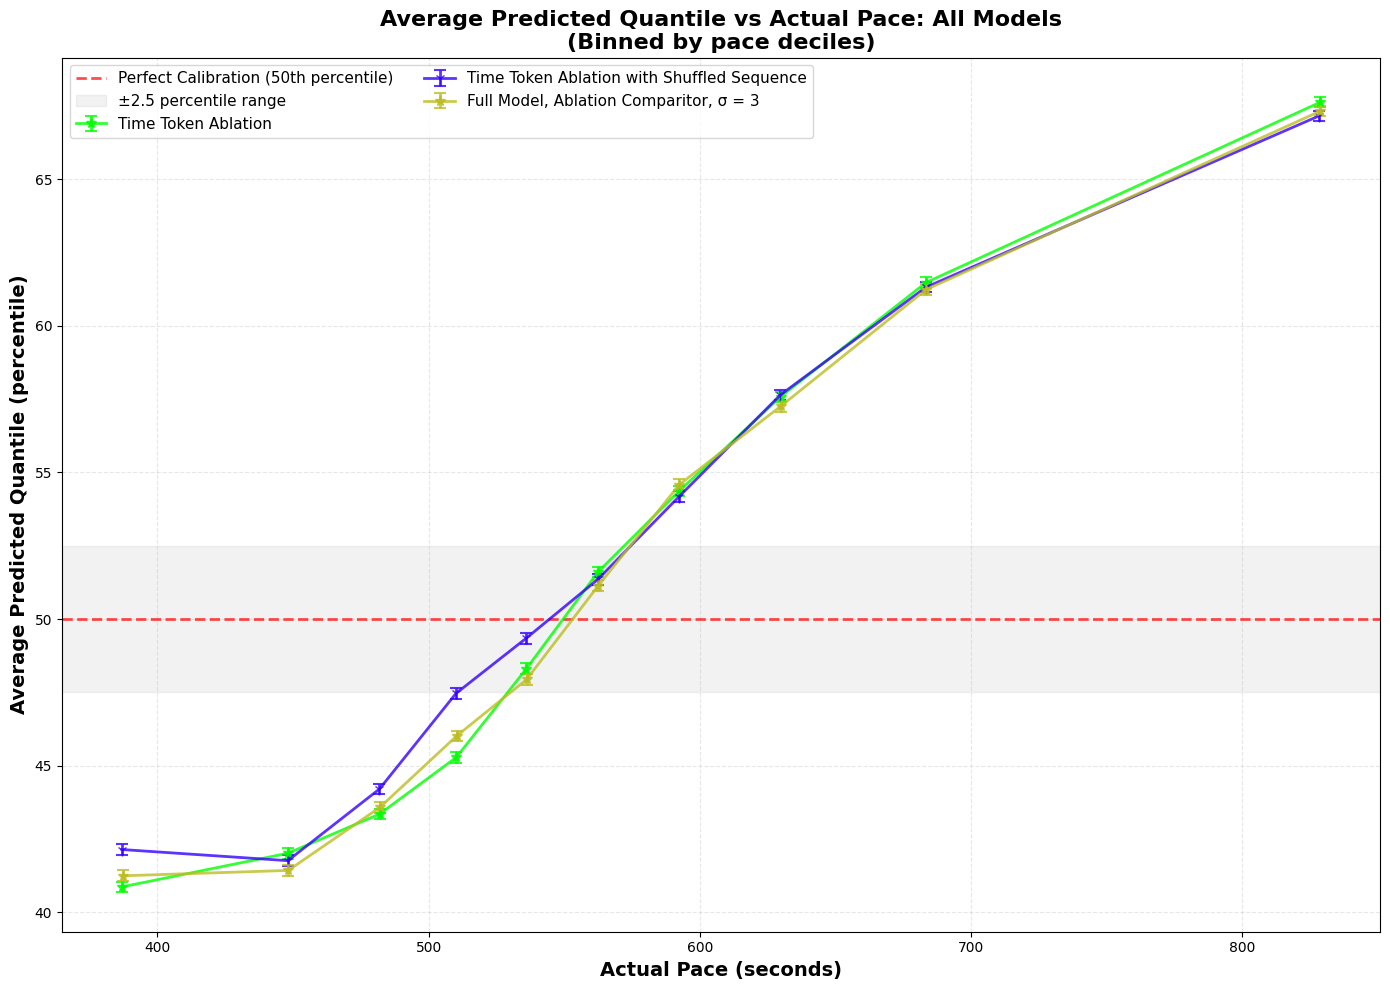

✓ Plotted 3 models on combined chart


In [85]:
# ========================================================================
# COMBINED PLOT: Average Predicted Quantile vs Actual Pace (All Models)
# ========================================================================
if 'quantile_plot_data' in globals() and len(quantile_plot_data) > 0:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot each model
    for model_name, data in quantile_plot_data.items():
        bin_centers = data['bin_centers']
        mean_percentiles = data['mean_percentiles']
        sem_percentiles = data['sem_percentiles']
        display_label = data['display_label']
        
        # Get color and marker for this model
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        
        # Plot with error bars
        ax.errorbar(bin_centers, mean_percentiles, yerr=sem_percentiles,
                   fmt=marker + '-', markersize=8, capsize=4, capthick=1.5,
                   linewidth=2, label=display_label, color=color, alpha=0.8)
    
    # Add horizontal line at 50 (perfect calibration)
    ax.axhline(y=50, color='r', linestyle='--', linewidth=2,
              label='Perfect Calibration (50th percentile)', alpha=0.7)
    
    # Add shaded region for ±2.5 percentile around 50
    ax.axhspan(50 - 2.5, 50 + 2.5, alpha=0.1, color='gray',
              label='±2.5 percentile range')
    
    ax.set_xlabel('Actual Pace (seconds)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Predicted Quantile (percentile)', fontsize=14, fontweight='bold')
    ax.set_title('Average Predicted Quantile vs Actual Pace: All Models\n(Binned by pace deciles)',
                fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='best', ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {len(quantile_plot_data)} models on combined chart")
else:
    print("⚠️  No quantile plot data available. Run Step 8 (Decile Analysis) first.")


## Step 10: Spearman Rank Correlation by Pace Decile (All Models)

Rank-order plot showing Spearman correlation coefficient between predicted and actual paces for each decile.
Higher values indicate better rank-order accuracy within each pace range.


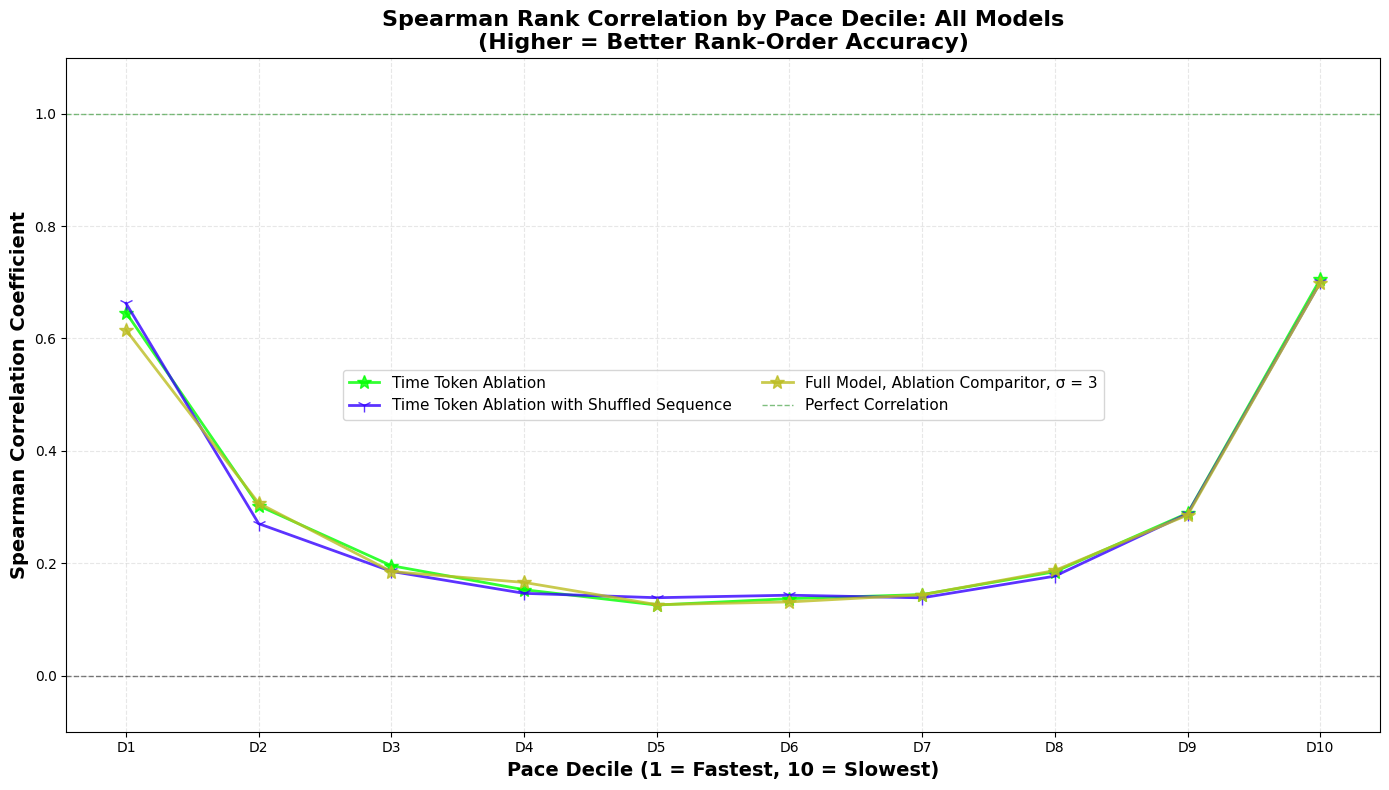

SPEARMAN CORRELATION SUMMARY BY DECILE
Decile   Pace Range                Time Token Ablation    Time Token Ablation    Full Model, Ablation  
--------------------------------------------------------------------------------
1        Decile 1                    0.6461                 0.6626                 0.6151                
2        Decile 2                    0.3022                 0.2703                 0.3067                
3        Decile 3                    0.1955                 0.1854                 0.1851                
4        Decile 4                    0.1528                 0.1463                 0.1657                
5        Decile 5                    0.1255                 0.1385                 0.1262                
6        Decile 6                    0.1368                 0.1430                 0.1310                
7        Decile 7                    0.1441                 0.1383                 0.1438                
8        Decile 8                 

In [86]:
# ========================================================================
# PLOT: Spearman Rank Correlation by Pace Decile (All Models)
# ========================================================================
if 'spearman_plot_data' in globals() and len(spearman_plot_data) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    decile_numbers = np.arange(1, 11)  # Deciles 1-10
    
    # Plot each model
    for model_name, data in spearman_plot_data.items():
        spearman_coefs = data['spearman_coefficients']
        display_label = data['display_label']
        
        # Get color and marker for this model
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        
        # Plot Spearman coefficient vs decile
        ax.plot(decile_numbers, spearman_coefs, marker=marker, markersize=10,
               linewidth=2, label=display_label, color=color, alpha=0.8)
    
    # Add horizontal line at 0 (no correlation)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add horizontal line at 1 (perfect correlation)
    ax.axhline(y=1, color='g', linestyle='--', linewidth=1, alpha=0.5, label='Perfect Correlation')
    
    ax.set_xlabel('Pace Decile (1 = Fastest, 10 = Slowest)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Spearman Correlation Coefficient', fontsize=14, fontweight='bold')
    ax.set_title('Spearman Rank Correlation by Pace Decile: All Models\n(Higher = Better Rank-Order Accuracy)',
                fontsize=16, fontweight='bold')
    ax.set_xticks(decile_numbers)
    ax.set_xticklabels([f'D{i}' for i in decile_numbers])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='best', ncol=2)
    ax.set_ylim(-0.1, 1.1)  # Spearman correlation ranges from -1 to 1
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("="*80)
    print("SPEARMAN CORRELATION SUMMARY BY DECILE")
    print("="*80)
    print(f"{'Decile':<8} {'Pace Range':<25}", end='')
    for model_name in spearman_plot_data.keys():
        display_label = spearman_plot_data[model_name]['display_label']
        print(f" {display_label[:20]:<22}", end='')
    print()
    print("-"*80)
    
    for decile_idx in range(10):
        print(f"{decile_idx+1:<8} Decile {decile_idx+1:<20}", end='')
        for model_name in spearman_plot_data.keys():
            spearman_coefs = spearman_plot_data[model_name]['spearman_coefficients']
            coef = spearman_coefs[decile_idx]
            if not np.isnan(coef):
                print(f" {coef:<22.4f}", end='')
            else:
                print(f" {'N/A':<22}", end='')
        print()
    
    print("="*80)
    print(f"✓ Plotted Spearman correlations for {len(spearman_plot_data)} models")
else:
    print("⚠️  No Spearman correlation data available. Run Step 8 (Decile Analysis) first.")


## Step 11: Global Spearman Rank Correlation (All Models)

Compute global Spearman correlation coefficient between predicted and actual paces across all examples (not broken down by decile).

This provides an overall measure of rank-order accuracy for each model, including baselines (XGBoost, Naive Mean, Last Race Pace, Riegel Formula).


In [87]:
# ========================================================================
# GLOBAL SPEARMAN CORRELATION FOR ALL MODELS
# ========================================================================
from scipy.stats import spearmanr

# Distance mapping (same as in evaluate_models.py, with additional tokens found in data)
DISTANCE_MAP = {
    'distance_name_token_1_mile': 1.0, 'distance_name_token_1POINT5_miles': 1.5,
    'distance_name_token_1POINT7_miles': 1.7,  # Found in evaluation logs
    'distance_name_token_3_miles': 3.0, 'distance_name_token_3_kilometers': 1.86411,
    'distance_name_token_5_kilometers': 3.10686, 'distance_name_token_4_miles': 4.0,
    'distance_name_token_5_miles': 5.0, 'distance_name_token_8_kilometers': 4.97097,
    'distance_name_token_10_kilometers': 6.21371, 'distance_name_token_12_kilometers': 7.45645,
    'distance_name_token_12_miles': 12.0,  # Found in evaluation logs
    'distance_name_token_15_kilometers': 9.32057, 'distance_name_token_10_miles': 10.0,
    'distance_name_token_18_miles': 18.0, 'distance_name_token_20_kilometers': 12.4274,
    'distance_name_token_25_kilometers': 15.5343, 'distance_name_token_30_kilometers': 18.6411,
    'distance_name_token_half_marathon': 13.1094, 'distance_name_token_marathon': 26.2188
}

# Helper functions to recompute baseline predictions (same as in evaluate_models.py)
def predict_naive_mean(example):
    """Predict global mean pace from historical races."""
    if not example.raw_pace_data or len(example.raw_pace_data) < 2:
        return None
    history = example.raw_pace_data[:-1]
    prev_paces = [h[2] for h in history]
    if len(prev_paces) == 0:
        return None
    return np.mean(prev_paces)

def predict_last_race_pace(example):
    """Predict last observed pace in history."""
    if not example.raw_pace_data or len(example.raw_pace_data) < 2:
        return None
    history = example.raw_pace_data[:-1]
    if len(history) == 0:
        return None
    return history[-1][2]  # Last race pace

def predict_riegel_formula(example):
    """Predict using Riegel formula: pace_new = pace_old * (distance_new/distance_old)^0.06"""
    if not example.raw_pace_data or len(example.raw_pace_data) < 2:
        return None
    
    # Get previous race (second to last) and target race (last)
    # raw_pace_data format: (distance_token, week_delta, pace)
    p1_d = example.raw_pace_data[-2]  # Previous race: (distance_token, week_delta, pace)
    p2_d = example.raw_pace_data[-1]  # Target race: (distance_token, week_delta, pace)
    
    d1 = DISTANCE_MAP.get(p1_d[0])  # Previous race distance in miles
    d2 = DISTANCE_MAP.get(p2_d[0])  # Target race distance in miles
    
    if d1 and d2 and d1 > 0:
        p_ri = float(p1_d[2]) * (d2 / d1) ** 0.06
        return p_ri
    return None

print("="*80)
print("GLOBAL SPEARMAN RANK CORRELATION (All Models)")
print("="*80)
print()

# Configuration: Sample size for Spearman correlation (to make computation faster)
SPEARMAN_SAMPLE_SIZE = 10000
SPEARMAN_RANDOM_SEED = 42  # For reproducibility

global_spearman_results = {}

# Get all models to evaluate - only models with stored predictions
all_models = set()
# Include transformer models that have stored predictions
for model_name in percentiles_by_model.keys():
    if model_name in results and 'predictions' in results[model_name] and 'actual_paces' in results[model_name]:
        all_models.add(model_name)
# Include XGBoost if it has stored predictions
if 'XGBoost' in results and 'predictions' in results['XGBoost'] and 'actual_paces' in results['XGBoost']:
    all_models.add('XGBoost')

# Include baselines if they have stored predictions
for baseline_name in ['NaiveMean', 'RiegelFormula']:
    if baseline_name in results and 'predictions' in results[baseline_name] and 'actual_paces' in results[baseline_name]:
        all_models.add(baseline_name)

print(f"Computing global Spearman correlation for {len(all_models)} models (with stored predictions)...")
print(f"Using random sample of {SPEARMAN_SAMPLE_SIZE} examples (for faster computation)")
print(f"Random seed: {SPEARMAN_RANDOM_SEED} (for reproducibility)")
print()

# Determine the maximum available sample size from all models
max_sample_size = 0
for model_name in all_models:
    if model_name in results and 'actual_paces' in results[model_name]:
        max_sample_size = max(max_sample_size, len(results[model_name]['actual_paces']))

# Use the minimum of requested sample size and available data
actual_sample_size = min(SPEARMAN_SAMPLE_SIZE, max_sample_size)
print(f"Available data: {max_sample_size} examples")
print(f"Sampling: {actual_sample_size} examples")
print()

# Generate random sample indices (same for all models for consistency)
np.random.seed(SPEARMAN_RANDOM_SEED)
sample_indices = np.random.choice(max_sample_size, size=actual_sample_size, replace=False)
sample_indices = np.sort(sample_indices)  # Sort for consistency
print()

# Process each model
for model_name in sorted(all_models):
    display_label = model_labels.get(model_name, model_name)
    print(f"Processing {display_label} ({model_name})...")
    
    # All models in all_models should have stored predictions
    if model_name in results and 'predictions' in results[model_name] and 'actual_paces' in results[model_name]:
        stored_predictions = results[model_name]['predictions']
        stored_actual_paces = results[model_name]['actual_paces']
        
        # Handle point predictions (XGBoost and baselines)
        if model_name == 'XGBoost' or model_name in ['NaiveMean', 'RiegelFormula']:
            # XGBoost and baselines: predictions is a list of predicted paces (point predictions)
            actual_paces_full = stored_actual_paces
            predicted_paces_full = stored_predictions
            baseline_label = 'baseline' if model_name in ['NaiveMean', 'RiegelFormula'] else 'XGBoost'
            print(f"  ✓ Using stored {model_name} predictions ({len(stored_actual_paces)} examples, {baseline_label})")
        else:
            # Transformer models: predictions is a dict with weighted_mean, weighted_median, mode_pace
            # Use weighted_median as the predicted pace (could also use weighted_mean or mode_pace)
            actual_paces_full = stored_actual_paces
            predicted_paces_full = stored_predictions['weighted_median']
            print(f"  ✓ Using stored predictions ({len(stored_actual_paces)} examples)")
        
        # Sample the data (use same indices for all models for consistency)
        n_available = len(actual_paces_full)
        if n_available > actual_sample_size:
            # Sample from available data using pre-computed sample_indices
            model_sample_indices = sample_indices[sample_indices < n_available]
            actual_paces_sampled = [actual_paces_full[i] for i in model_sample_indices]
            predicted_paces_sampled = [predicted_paces_full[i] for i in model_sample_indices]
            print(f"    Sampled {len(actual_paces_sampled)} examples from {n_available} available")
        else:
            # Use all available data if less than sample size
            actual_paces_sampled = actual_paces_full
            predicted_paces_sampled = predicted_paces_full
            print(f"    Using all {n_available} examples (less than sample size)")
    else:
        print(f"  ⚠️  Skipping {model_name} - no stored predictions available")
        continue
    
    # Compute global Spearman correlation on sampled data
    if len(actual_paces_sampled) > 1 and len(predicted_paces_sampled) > 1:
        actual_paces_arr = np.array(actual_paces_sampled)
        predicted_paces_arr = np.array(predicted_paces_sampled)
        
        # Count ties for diagnostic
        n_unique_actual = len(np.unique(actual_paces_arr))
        n_unique_predicted = len(np.unique(predicted_paces_arr))
        n_ties_actual = len(actual_paces_arr) - n_unique_actual
        n_ties_predicted = len(predicted_paces_arr) - n_unique_predicted
        
        spearman_coef, spearman_pval = spearmanr(actual_paces_arr, predicted_paces_arr)
        
        global_spearman_results[model_name] = {
            'spearman_coef': spearman_coef,
            'spearman_pval': spearman_pval,
            'n_examples': len(actual_paces_arr),
            'n_ties_actual': n_ties_actual,
            'n_ties_predicted': n_ties_predicted,
            'display_label': display_label
        }
        
        print(f"  ✓ Global Spearman: {spearman_coef:.4f} (p={spearman_pval:.2e}, n={len(actual_paces_arr)})")
        if n_ties_actual > len(actual_paces_arr) * 0.1 or n_ties_predicted > len(predicted_paces_arr) * 0.1:
            print(f"    Note: {n_ties_actual} ties in actual, {n_ties_predicted} ties in predicted")
    else:
        print(f"  ⚠️  Insufficient data: {len(actual_paces_list)} examples")

print()
print("="*80)
print("GLOBAL SPEARMAN CORRELATION RESULTS")
print("="*80)
if actual_sample_size < max_sample_size:
    print(f"Note: Results based on random sample of {actual_sample_size} examples (from {max_sample_size} available)")
    print(f"      Random seed: {SPEARMAN_RANDOM_SEED} (for reproducibility)")
else:
    print(f"Note: Using all {max_sample_size} available examples")
print()

if len(global_spearman_results) > 0:
    # Sort by Spearman coefficient (descending)
    sorted_results = sorted(global_spearman_results.items(), 
                           key=lambda x: x[1]['spearman_coef'], 
                           reverse=True)
    
    print(f"{'Rank':<6} {'Model':<40} {'Spearman ρ':<15} {'P-value':<15} {'N':<10} {'Ties (act/pred)':<20}")
    print("-"*110)
    
    for rank, (model_name, data) in enumerate(sorted_results, 1):
        display_label = data['display_label']
        coef = data['spearman_coef']
        pval = data['spearman_pval']
        n = data['n_examples']
        ties_act = data['n_ties_actual']
        ties_pred = data['n_ties_predicted']
        
        # Format p-value
        if pval < 0.001:
            pval_str = f"{pval:.2e}"
        else:
            pval_str = f"{pval:.4f}"
        
        print(f"{rank:<6} {display_label:<40} {coef:<15.4f} {pval_str:<15} {n:<10} {ties_act}/{ties_pred}")
    
    print()
    print("="*80)
    print("INTERPRETATION:")
    print("  - Spearman ρ ranges from -1 to +1")
    print("  - Higher values indicate better rank-order accuracy")
    print("  - ρ = 1: Perfect rank-order correlation")
    print("  - ρ = 0: No rank-order correlation")
    print("  - Ties are handled using average rank (midrank) method")
    print("="*80)
else:
    print("⚠️  No global Spearman correlation results computed.")


GLOBAL SPEARMAN RANK CORRELATION (All Models)

Computing global Spearman correlation for 6 models (with stored predictions)...
Using random sample of 10000 examples (for faster computation)
Random seed: 42 (for reproducibility)

Available data: 247173 examples
Sampling: 10000 examples


Processing Naive Mean (NaiveMean)...
  ✓ Using stored NaiveMean predictions (247173 examples, baseline)
    Sampled 10000 examples from 247173 available
  ✓ Global Spearman: 0.8072 (p=0.00e+00, n=10000)
    Note: 9263 ties in actual, 3360 ties in predicted
Processing Riegel Formula (RiegelFormula)...
  ✓ Using stored RiegelFormula predictions (244484 examples, baseline)
    Sampled 9887 examples from 244484 available
  ✓ Global Spearman: 0.8260 (p=0.00e+00, n=9887)
    Note: 9147 ties in actual, 3316 ties in predicted
Processing XGBoost (XGBoost)...
  ✓ Using stored XGBoost predictions (247173 examples, XGBoost)
    Sampled 10000 examples from 247173 available
  ✓ Global Spearman: 0.8857 (p=0.00e+00, n=